# Section 1 — Data Pipeline

*In practice: this is the unglamorous infrastructure work every quant desk depends on — nobody trusts a signal built on data nobody can reproduce.*

Write a function (or small collection of functions) that fetches daily adjusted closing prices for the twelve tickers above using `yfinance`. The function must implement a **disk cache**: on the first call it downloads the data and saves it to a local file (e.g., a CSV or Parquet); on subsequent calls it reads from disk and only queries the internet if the locally stored data does not cover the most recent available trading day.

The pipeline should return a clean `DataFrame` of **daily log returns** (or percent returns — be explicit about which you choose and be consistent throughout the notebook), with dates as the index and tickers as columns, with `NaN` rows dropped.

Your cache should behave correctly across different machines and be easy for a grader to reproduce. Include a brief prose cell explaining your cache invalidation logic.

he universe is the eleven SPDR sector ETFs — **XLC, XLY, XLP, XLE, XLF, XLV, XLI, XLB, XLRE, XLK, XLU** — plus the S&P 500 index ETF **SPY** as the market factor.

In [80]:
tickers = "XLC, XLY, XLP, XLE, XLF, XLV, XLI, XLB, XLRE, XLK, XLU, SPY".split(", ")

In [81]:
import pandas as pd
import yfinance as yf
from pathlib import Path
import numpy as np

RANDOM_SEED = 2026


In [82]:
from pandas.tseries.holiday import (
    AbstractHolidayCalendar, Holiday, USMartinLutherKingJr,
    USPresidentsDay, GoodFriday, USMemorialDay, USLaborDay,
    USThanksgivingDay, nearest_workday, sunday_to_monday,
)


class NYSEHolidays(AbstractHolidayCalendar):
    # NYSE does not observe Saturday New Year's Day on the preceding Friday.
    rules = [
        Holiday("New Year", month=1, day=1, observance=sunday_to_monday),
        USMartinLutherKingJr,
        USPresidentsDay,
        GoodFriday,
        USMemorialDay,
        Holiday("Juneteenth", month=6, day=19, start_date="2022-01-01",
                observance=nearest_workday),
        Holiday("Independence Day", month=7, day=4, observance=nearest_workday),
        USLaborDay,
        USThanksgivingDay,
        Holiday("Christmas", month=12, day=25, observance=nearest_workday),
    ]


# Known exceptional full-day closures since the download start date.
NYSE_EXTRA_CLOSURES = pd.to_datetime([
    "2001-09-11", "2001-09-12", "2001-09-13", "2001-09-14",
    "2004-06-11", "2007-01-02", "2012-10-29", "2012-10-30",
    "2018-12-05", "2025-01-09",
])


def latest_completed_session(now=None):
    """Find the last completed NYSE session using pandas, without a network call."""
    now = pd.Timestamp.now(tz="UTC") if now is None else pd.Timestamp(now)
    now = now.tz_localize("UTC") if now.tzinfo is None else now
    now = now.tz_convert("America/New_York")
    today = now.tz_localize(None).normalize()
    start = today - pd.Timedelta(days=30)
    holidays = NYSEHolidays().holidays(start=start, end=today)
    holidays = holidays.union(NYSE_EXTRA_CLOSURES)

    for day in pd.date_range(start, today)[::-1]:
        if day.weekday() >= 5 or day in holidays:
            continue
        # Regular equities close at 16:00 Eastern; scheduled half-days at 13:00.
        after_thanksgiving = (
            day.month == 11 and day.weekday() == 4 and 23 <= day.day <= 29
        )
        early_close = (
            after_thanksgiving
            or (day.month == 7 and day.day == 3)
            or (day.month == 12 and day.day == 24)
        )
        close = (day + pd.Timedelta(hours=13 if early_close else 16)).tz_localize(
            "America/New_York"
        )
        if close <= now:
            return day
    raise ValueError("No completed session found in the last 30 days.")


def load_daily_returns(tickers, cache_path="./ticker_cache", now=None):
    """Load simple daily returns through the latest completed NYSE session."""
    last_session = latest_completed_session(now)
    cache_path = Path(cache_path)
    cache_path.mkdir(parents=True, exist_ok=True)
    # Separate from the old timer cache, which could contain an intraday bar.
    data_path = cache_path / "completed_daily_returns.csv"

    if data_path.exists():
        cached = pd.read_csv(data_path, index_col=0, parse_dates=True)
        if set(tickers).issubset(cached.columns):
            cached = cached.loc[cached.index <= last_session, tickers].sort_index().dropna()
            if not cached.empty and cached.index[-1] == last_session:
                return cached

    # yfinance's end date is exclusive; never include an unfinished session.
    end_date = (last_session + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    prices = yf.download(
        tickers,
        start="2000-01-01",
        end=end_date,
        auto_adjust=True,
        threads=True,
    )["Close"]
    prices = prices.loc[prices.index <= last_session, tickers].sort_index()
    returns = prices.pct_change(fill_method=None).dropna()
    if returns.empty:
        raise ValueError("Download produced no complete daily returns; cache preserved.")
    if returns.index[-1] < last_session:
        print(
            f"Latest completed NYSE session: {last_session.date()}; "
            f"latest complete data for all tickers: {returns.index[-1].date()}. "
            "The cache will be checked for missing data on the next call."
        )

    returns.to_csv(data_path)
    return returns


df = load_daily_returns(tickers)
print(f"Returns through latest available completed session: {df.index[-1].date()}")
df.head()


[*********************100%***********************]  12 of 12 completed

Latest completed NYSE session: 2026-09-16; latest complete data for all tickers: 2026-09-15. The cache will be checked for missing data on the next call.
Returns through latest available completed session: 2026-09-15


Ticker,XLC,XLY,XLP,XLE,XLF,XLV,XLI,XLB,XLRE,XLK,XLU,SPY
Date,,,,,,,,,,,,
2018-06-20,0.012410,0.004742,0.000979,0.004415,-0.002559,0.002121,0.000683,-0.003248,0.010794,0.002100,0.000797,0.001706
2018-06-21,-0.006129,-0.007123,0.001956,-0.018516,-0.002933,-0.005762,-0.012555,-0.010635,0.005967,-0.007684,0.003385,-0.006269
2018-06-22,0.004377,-0.001704,0.008202,0.019951,-0.004779,0.004494,0.003455,0.014563,0.008742,-0.003238,0.006944,0.001823
2018-06-25,-0.020598,-0.021739,0.005036,-0.020093,-0.010713,-0.009184,-0.012670,-0.015550,-0.002476,-0.020763,0.016552,-0.013613
2018-06-26,0.001658,0.007162,-0.004240,0.012629,-0.003361,-0.003090,0.003766,0.003819,0.005275,0.004038,0.001163,0.002214


Returns are simple daily returns, computed from adjusted closing prices without filling missing prices. The cache also checks for holidays and weekends so the data is updated to the most recent trading day.

Random simulations and bootstrap resampling use a fixed seed.

## Section 2 — Parameter and Model Uncertainty

*In practice: this is what risk and model-validation teams call "parameter risk" or "model risk" — before a strategy ever touches real capital, someone has to answer "how much do we actually trust these inputs?"*

The central inputs to portfolio optimization are (estimates of) $\boldsymbol{\mu}$ and $\boldsymbol{\Sigma}$. Before we ever optimize, we should ask: **how well can we actually estimate these?**

### 2.1 — Simulation Study (No Model Risk)

Suppose the *true* return distribution is multivariate normal with some known $\boldsymbol{\mu}^*$ and $\boldsymbol{\Sigma}^*$ (use your full-sample estimates from the sector ETF data as the "ground truth"). For sample sizes $n \in \{63, 126, 252, 504, 1008, 2520\}$ (roughly one quarter, one half year, one year, two years, four years, and ten years of trading days):

- Simulate many independent samples of size $n$ from $\mathcal{N}(\boldsymbol{\mu}^*, \boldsymbol{\Sigma}^*)$.
- For each sample, compute the sample mean $\hat{\boldsymbol{\mu}}$ and sample covariance $\hat{\boldsymbol{\Sigma}}$.
- Summarize, across simulations, the estimation error for both $\boldsymbol{\mu}$ and $\boldsymbol{\Sigma}$.

Produce visualizations that make a clear and honest case for how reliable the estimates are at each $n$. Some quantities you might consider: element-wise RMSE, the Frobenius norm of $\hat{\boldsymbol{\Sigma}} - \boldsymbol{\Sigma}^*$, the distribution of $\hat{\mu}_i - \mu_i^*$ for a few assets, or the distribution of estimated Sharpe ratios for a fixed $\mathbf{w}$. You are encouraged to go beyond these suggestions. Write a brief interpretation: at what sample sizes are the estimates "good enough" for practical use, and are $\boldsymbol{\mu}$ and $\boldsymbol{\Sigma}$ equally reliable?

In [83]:
from collections import defaultdict

rng_sim = np.random.default_rng(RANDOM_SEED)

n = [63, 126, 252, 504, 1008, 2520]
sectors = tickers[:-1]

mu = df[sectors].mean().values
cov = df[sectors].cov().values

error_mus = defaultdict(list)
error_covs = defaultdict(list)

for _ in range(100):
    for k in n:
        samples = rng_sim.multivariate_normal(mu, cov, size=k)

        mu_hat = samples.mean(axis=0)
        cov_hat = np.cov(samples.T)

        error_mus[k].append(
            np.sqrt(np.mean((mu_hat - mu) ** 2))
        )

        error_covs[k].append(
            np.linalg.norm(cov_hat - cov, "fro")
        )

error_summary = pd.DataFrame({
    "Mean RMSE (mu)": [np.mean(error_mus[k]) for k in n],
    "Mean Frobenius Error (cov)": [np.mean(error_covs[k]) for k in n]
}, index=n)

error_summary["Annualized Mean RMSE"] = (
    error_summary["Mean RMSE (mu)"] * 252
)

error_summary

,Mean RMSE (mu),Mean Frobenius Error (cov),Annualized Mean RMSE
63,0.001571,0.000309,0.395877
126,0.001057,0.000219,0.266279
252,0.000838,0.000160,0.211215
504,0.000600,0.000126,0.151216
1008,0.000452,0.000082,0.113852
2520,0.000265,0.000046,0.066845


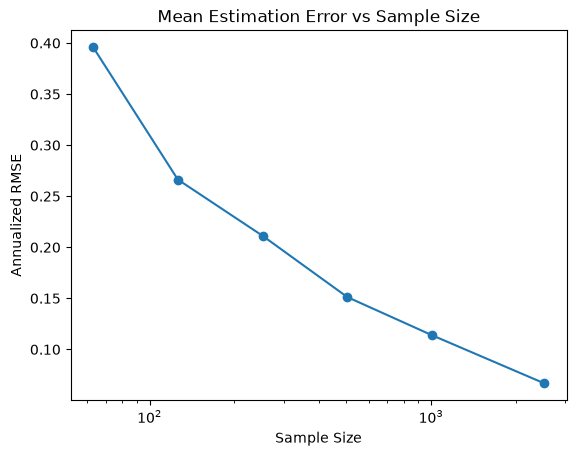

In [84]:
from matplotlib import pyplot as plt
plt.plot(
    error_summary.index,
    error_summary["Annualized Mean RMSE"],
    marker="o"
)

plt.xscale("log")
plt.xlabel("Sample Size")
plt.ylabel("Annualized RMSE")
plt.title("Mean Estimation Error vs Sample Size")
plt.show()

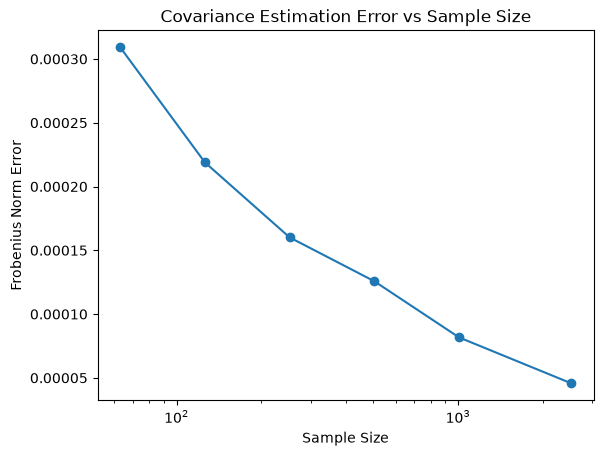

In [85]:
plt.plot(
    error_summary.index,
    error_summary["Mean Frobenius Error (cov)"],
    marker="o"
)

plt.xscale("log")
plt.xlabel("Sample Size")
plt.ylabel("Frobenius Norm Error")
plt.title("Covariance Estimation Error vs Sample Size")
plt.show()

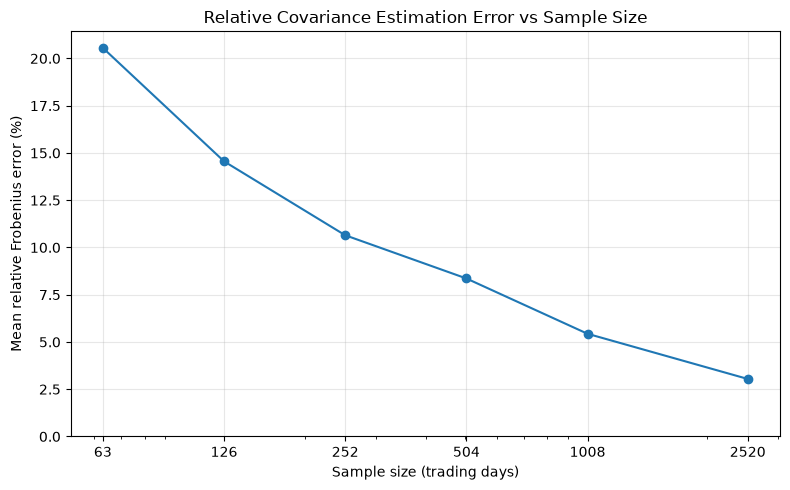

In [86]:
# Normalize aggregate covariance error by the ground-truth matrix norm.
error_summary["Relative Frobenius Error (cov)"] = (
    error_summary["Mean Frobenius Error (cov)"]
    / np.linalg.norm(cov, "fro")
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    error_summary.index,
    error_summary["Relative Frobenius Error (cov)"] * 100,
    marker="o",
)
ax.set_xscale("log")
ax.set_xticks(error_summary.index)
ax.set_xticklabels(error_summary.index)
ax.set_xlabel("Sample size (trading days)")
ax.set_ylabel("Mean relative Frobenius error (%)")
ax.set_title("Relative Covariance Estimation Error vs Sample Size")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

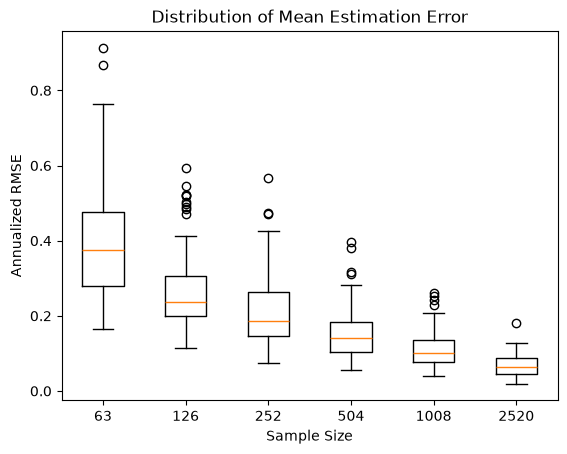

In [87]:
plt.boxplot(
    [np.array(error_mus[k]) * 252 for k in n],
    tick_labels=n
)

plt.xlabel("Sample Size")
plt.ylabel("Annualized RMSE")
plt.title("Distribution of Mean Estimation Error")
plt.show()

Annualized mean estimation RMSE falls from 39.6 percentage points at 63 days to 21.1 at 252 and 6.7 at 2,520. Even the covariance estimates have substantial relative error, only going below 10% at 504 days in the tested grid, or about 2 years of data. I would consider that a more useful level of covariance accuracy, although it does not guarantee stable portfolio weights. Given the difficulty of estimating the mean, it might be better to explore options that only need the covariance of stocks rather than their mean. I would still be cautious about using any of these mean estimates directly for trading.

### 2.2 — Model Uncertainty on Real Data

Now use the actual sector ETF returns. Estimate $\boldsymbol{\mu}$ and $\boldsymbol{\Sigma}$ under at least two different approaches:

- **Sample moments**: sample mean vector and sample covariance matrix.
- **CAPM**: multivariate OLS with SPY as the single factor (as derived in module 2), then use the law of total expectation and law of total covariance to obtain $\hat{\boldsymbol{\mu}}$ and $\hat{\boldsymbol{\Sigma}}$.

For each pair of estimates, report the full mean vector and covariance matrix (or correlation matrix — your choice). How different are the estimates across methods? Which elements differ the most? What does that tell you about model sensitivity?

In [88]:
import statsmodels.api as sm

market = df["SPY"]
X = sm.add_constant(market)

alphas = []
betas = []
residual_vars = []

for sector in sectors:
    model = sm.OLS(df[sector], X).fit()

    alphas.append(model.params["const"])
    betas.append(model.params["SPY"])
    residual_vars.append(model.resid.var())

alphas = np.array(alphas)
betas = np.array(betas)
residual_vars = np.array(residual_vars)

capm_parameters = pd.DataFrame({
    "alpha": alphas,
    "beta": betas,
    "residual variance": residual_vars
}, index=sectors)

capm_parameters

,alpha,beta,residual variance
XLC,-0.000078,0.985722,0.000053
XLY,-0.000209,1.112449,0.000046
XLP,0.000065,0.525765,0.000057
XLE,0.000058,0.943053,0.000268
XLF,-0.000091,1.006489,0.000066
XLV,0.000029,0.687400,0.000052
XLI,-0.000046,0.973761,0.000042
XLB,-0.000146,0.944388,0.000061
XLRE,-0.000125,0.808069,0.000092
XLK,0.000171,1.287778,0.000043


In [89]:
market_mu = market.mean()

mu_capm = alphas + betas * market_mu

mu_capm = pd.Series(
    mu_capm,
    index=sectors
)

mu_capm

XLC     0.000534
XLY     0.000481
XLP     0.000391
XLE     0.000643
XLF     0.000534
XLV     0.000456
XLI     0.000558
XLB     0.000440
XLRE    0.000376
XLK     0.000970
XLU     0.000444
dtype: float64

In [90]:
market_var = market.var()
market_cov = np.outer(betas, betas) * market_var
cov_capm = (
    market_cov
    + np.diag(residual_vars)
)

cov_capm = pd.DataFrame(
    cov_capm,
    index=sectors,
    columns=sectors
)

cov_capm

,XLC,XLY,XLP,XLE,XLF,XLV,XLI,XLB,XLRE,XLK,XLU
XLC,0.000194,0.000160,0.000075,0.000135,0.000144,0.000099,0.000140,0.000136,0.000116,0.000185,0.000087
XLY,0.000160,0.000226,0.000085,0.000153,0.000163,0.000111,0.000158,0.000153,0.000131,0.000209,0.000098
XLP,0.000075,0.000085,0.000097,0.000072,0.000077,0.000053,0.000075,0.000072,0.000062,0.000099,0.000046
XLE,0.000135,0.000153,0.000072,0.000398,0.000138,0.000094,0.000134,0.000130,0.000111,0.000177,0.000083
XLF,0.000144,0.000163,0.000077,0.000138,0.000213,0.000101,0.000143,0.000138,0.000118,0.000189,0.000089
XLV,0.000099,0.000111,0.000053,0.000094,0.000101,0.000121,0.000097,0.000094,0.000081,0.000129,0.000061
XLI,0.000140,0.000158,0.000075,0.000134,0.000143,0.000097,0.000180,0.000134,0.000115,0.000183,0.000086
XLB,0.000136,0.000153,0.000072,0.000130,0.000138,0.000094,0.000134,0.000191,0.000111,0.000177,0.000083
XLRE,0.000116,0.000131,0.000062,0.000111,0.000118,0.000081,0.000115,0.000111,0.000187,0.000151,0.000071
XLK,0.000185,0.000209,0.000099,0.000177,0.000189,0.000129,0.000183,0.000177,0.000151,0.000284,0.000114


In [91]:
mu_comparison = pd.DataFrame({
    "Sample": mu,
    "CAPM": mu_capm
})

mu_comparison["Difference"] = (
    mu_comparison["CAPM"]
    - mu_comparison["Sample"]
)

mu_comparison

,Sample,CAPM,Difference
XLC,0.000534,0.000534,0.000000e+00
XLY,0.000481,0.000481,-1.029992e-18
XLP,0.000391,0.000391,-2.710505e-19
XLE,0.000643,0.000643,-3.252607e-19
XLF,0.000534,0.000534,-4.336809e-19
XLV,0.000456,0.000456,-3.252607e-19
XLI,0.000558,0.000558,-7.589415e-19
XLB,0.000440,0.000440,-4.336809e-19
XLRE,0.000376,0.000376,-2.168404e-19
XLK,0.000970,0.000970,-1.301043e-18


In [92]:
def cov_to_corr(cov):
    std = np.sqrt(np.diag(cov))
    return cov / np.outer(std, std)

corr_sample = cov_to_corr(cov)
corr_capm = cov_to_corr(cov_capm)

corr_sample = pd.DataFrame(
    corr_sample,
    index=sectors,
    columns=sectors
)

corr_capm = pd.DataFrame(
    corr_capm,
    index=sectors,
    columns=sectors
)

In [93]:
corr_sample

,XLC,XLY,XLP,XLE,XLF,XLV,XLI,XLB,XLRE,XLK,XLU
XLC,1.000000,0.806560,0.529400,0.412743,0.664374,0.614490,0.668189,0.648653,0.577804,0.780613,0.412213
XLY,0.806560,1.000000,0.532225,0.435722,0.715726,0.605882,0.759755,0.723721,0.624109,0.808210,0.430048
XLP,0.529400,0.532225,1.000000,0.387415,0.606202,0.711632,0.612768,0.629050,0.692580,0.448599,0.698308
XLE,0.412743,0.435722,0.387415,1.000000,0.665620,0.434544,0.636673,0.626859,0.441591,0.397516,0.369167
XLF,0.664374,0.715726,0.606202,0.665620,1.000000,0.663588,0.860970,0.810542,0.671042,0.634852,0.538165
XLV,0.614490,0.605882,0.711632,0.434544,0.663588,1.000000,0.681048,0.681028,0.673927,0.587411,0.593472
XLI,0.668189,0.759755,0.612768,0.636673,0.860970,0.681048,1.000000,0.870299,0.695047,0.721809,0.577948
XLB,0.648653,0.723721,0.629050,0.626859,0.810542,0.681028,0.870299,1.000000,0.686999,0.664201,0.562816
XLRE,0.577804,0.624109,0.692580,0.441591,0.671042,0.673927,0.695047,0.686999,1.000000,0.540896,0.747550
XLK,0.780613,0.808210,0.448599,0.397516,0.634852,0.587411,0.721809,0.664201,0.540896,1.000000,0.401282


In [94]:
corr_capm

,XLC,XLY,XLP,XLE,XLF,XLV,XLI,XLB,XLRE,XLK,XLU
XLC,1.000000,0.761978,0.550089,0.487138,0.710244,0.643314,0.747479,0.704634,0.607987,0.786953,0.486696
XLY,0.761978,1.000000,0.575020,0.509216,0.742433,0.672471,0.781357,0.736570,0.635542,0.822619,0.508754
XLP,0.550089,0.575020,1.000000,0.367615,0.535980,0.485472,0.564079,0.531747,0.458812,0.593867,0.367281
XLE,0.487138,0.509216,0.367615,1.000000,0.474643,0.429916,0.499527,0.470895,0.406307,0.525906,0.325250
XLF,0.710244,0.742433,0.535980,0.474643,1.000000,0.626813,0.728307,0.686561,0.592392,0.766767,0.474212
XLV,0.643314,0.672471,0.485472,0.429916,0.626813,1.000000,0.659675,0.621863,0.536568,0.694512,0.429525
XLI,0.747479,0.781357,0.564079,0.499527,0.728307,0.659675,1.000000,0.722555,0.623449,0.806966,0.499074
XLB,0.704634,0.736570,0.531747,0.470895,0.686561,0.621863,0.722555,1.000000,0.587713,0.760712,0.470467
XLRE,0.607987,0.635542,0.458812,0.406307,0.592392,0.536568,0.623449,0.587713,1.000000,0.656372,0.405938
XLK,0.786953,0.822619,0.593867,0.525906,0.766767,0.694512,0.806966,0.760712,0.656372,1.000000,0.525429


Largest absolute correlation differences (CAPM minus sample):


,Sample covariance,CAPM covariance,Covariance difference,Sample correlation,CAPM correlation,Correlation difference
Pair,,,,,,
XLRE–XLU,0.000131,0.000071,-0.000060,0.747550,0.405938,-0.341612
XLP–XLU,0.000088,0.000046,-0.000042,0.698308,0.367281,-0.331027
XLP–XLRE,0.000093,0.000062,-0.000032,0.692580,0.458812,-0.233768
XLP–XLV,0.000077,0.000053,-0.000025,0.711632,0.485472,-0.226160
XLE–XLF,0.000194,0.000138,-0.000056,0.665620,0.474643,-0.190977


Largest absolute covariance differences (daily return-squared units):


,Sample covariance,CAPM covariance,Covariance difference
Pair,,,
XLRE–XLU,0.000131,0.000071,-0.000060
XLE–XLF,0.000194,0.000138,-0.000056
XLE–XLK,0.000134,0.000177,0.000043
XLE–XLB,0.000173,0.000130,-0.000043
XLP–XLU,0.000088,0.000046,-0.000042


Largest absolute daily mean difference: 1.30e-18
Largest absolute variance difference: 7.59e-19
Relative Frobenius difference between covariance estimates: 15.34%


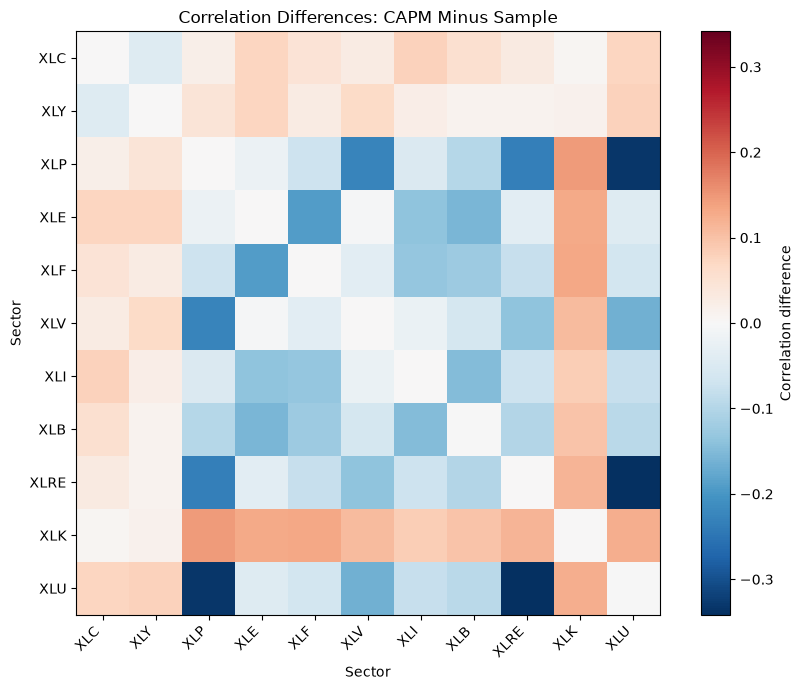

In [95]:
# Compare each distinct pair once; differences are CAPM minus sample.
cov_sample = pd.DataFrame(cov, index=sectors, columns=sectors)
cov_difference = cov_capm - cov_sample
corr_difference = corr_capm - corr_sample
pair_i, pair_j = np.triu_indices(len(sectors), k=1)

pair_comparison = pd.DataFrame({
    "Pair": [f"{sectors[i]}–{sectors[j]}" for i, j in zip(pair_i, pair_j)],
    "Sample covariance": cov_sample.to_numpy()[pair_i, pair_j],
    "CAPM covariance": cov_capm.to_numpy()[pair_i, pair_j],
    "Covariance difference": cov_difference.to_numpy()[pair_i, pair_j],
    "Sample correlation": corr_sample.to_numpy()[pair_i, pair_j],
    "CAPM correlation": corr_capm.to_numpy()[pair_i, pair_j],
    "Correlation difference": corr_difference.to_numpy()[pair_i, pair_j],
}).set_index("Pair")

print("Largest absolute correlation differences (CAPM minus sample):")
display(pair_comparison.loc[
    pair_comparison["Correlation difference"].abs().nlargest(5).index
])
print("Largest absolute covariance differences (daily return-squared units):")
display(pair_comparison.loc[
    pair_comparison["Covariance difference"].abs().nlargest(5).index,
    ["Sample covariance", "CAPM covariance", "Covariance difference"],
])

relative_cov_difference = (
    np.linalg.norm(cov_difference.to_numpy(), "fro")
    / np.linalg.norm(cov, "fro")
)
print(f"Largest absolute daily mean difference: {mu_comparison['Difference'].abs().max():.2e}")
print(f"Largest absolute variance difference: {np.abs(np.diag(cov_difference)).max():.2e}")
print(f"Relative Frobenius difference between covariance estimates: {relative_cov_difference:.2%}")

fig, ax = plt.subplots(figsize=(9, 7))
color_limit = np.abs(corr_difference.to_numpy()).max()
heatmap = ax.imshow(
    corr_difference, cmap="RdBu_r", vmin=-color_limit, vmax=color_limit,
)
ax.set_xticks(range(len(sectors)), labels=sectors, rotation=45, ha="right")
ax.set_yticks(range(len(sectors)), labels=sectors)
ax.set_xlabel("Sector")
ax.set_ylabel("Sector")
ax.set_title("Correlation Differences: CAPM Minus Sample")
fig.colorbar(heatmap, ax=ax, label="Correlation difference")
plt.tight_layout()
plt.show()


The mean estimates are effectively identical because the OLS intercept makes the average residual zero, so the CAPM estimate recovers the sample mean. I would not take this as evidence that the means are accurate, especially given the estimation errors in 2.1. The individual variances also match, but the covariances differ because the model assumes the sector residuals are uncorrelated.

The largest correlation difference is XLRE–XLU, falling from 0.748 in the sample to 0.406 under CAPM. XLP–XLU also falls from 0.698 to 0.367. XLRE–XLU has the largest covariance difference as well, going from 0.000131 to 0.000071. These sectors move together more than their exposure to SPY alone explains, so the model leaves out part of their relationship.

Overall, the covariance estimates differ by 15.3% relative to the sample matrix's Frobenius norm. This measures disagreement between the methods rather than error against a known truth. I would say the choice of model matters here, since the lower correlations make these pairs look more diversified and could lead to different portfolio allocations. The simpler model might reduce estimation noise, but these results alone do not show whether it would perform better on new data.

### 2.3 — Bootstrap and Rolling Window

Choose one estimation method from 2.2. Using the same data:

- **Bootstrap**: resample the daily return rows with replacement 500–1000 times. For each resample, compute $\hat{\boldsymbol{\mu}}$ and $\hat{\boldsymbol{\Sigma}}$. Visualize the resulting distributions. For instance: plot the bootstrap distribution of $\hat{\mu}_i$ for each sector with a confidence band; plot the distribution of $\hat{\Sigma}_{ij}$ for a selection of covariance pairs.

- **Rolling window**: compute $\hat{\boldsymbol{\mu}}$ and $\hat{\boldsymbol{\Sigma}}$ using a rolling 252-day window. Plot how these estimates evolve over time. Are there identifiable regimes? Do any estimates look stable, or are they volatile?

Write at least one paragraph interpreting what you observe, with specific reference to your figures.


In [96]:
rng_boot = np.random.default_rng(RANDOM_SEED + 1)

boot_mus = []
boot_covs = []

for _ in range(1000):
    sample = df[sectors].sample(len(df), replace=True, random_state=rng_boot)

    boot_mus.append(sample.mean().values)
    boot_covs.append(sample.cov().values)

boot_mus = np.array(boot_mus)
boot_covs = np.array(boot_covs)

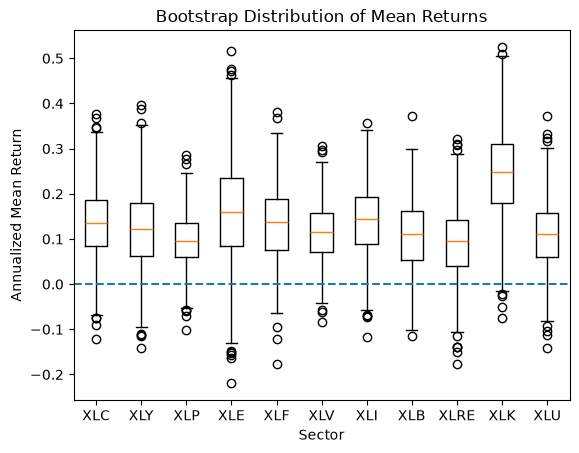

In [97]:
plt.boxplot(
    boot_mus * 252,
    tick_labels=sectors
)

plt.axhline(0, linestyle="--")
plt.xlabel("Sector")
plt.ylabel("Annualized Mean Return")
plt.title("Bootstrap Distribution of Mean Returns")
plt.show()

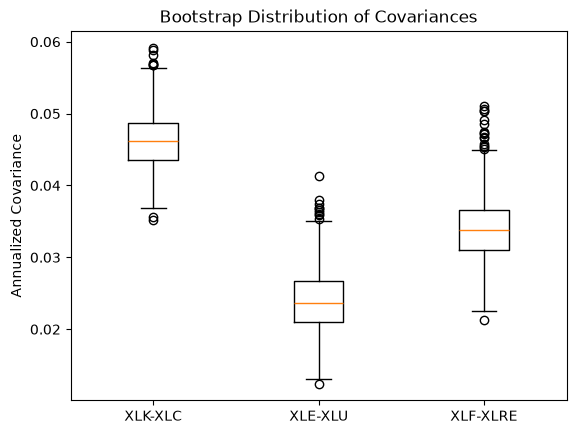

In [98]:
pairs = [
    ("XLK", "XLC"),
    ("XLE", "XLU"),
    ("XLF", "XLRE")
]

pair_covs = [
    boot_covs[:, sectors.index(a), sectors.index(b)] * 252
    for a, b in pairs
]

plt.boxplot(
    pair_covs,
    tick_labels=[f"{a}-{b}" for a, b in pairs]
)

plt.ylabel("Annualized Covariance")
plt.title("Bootstrap Distribution of Covariances")
plt.show()

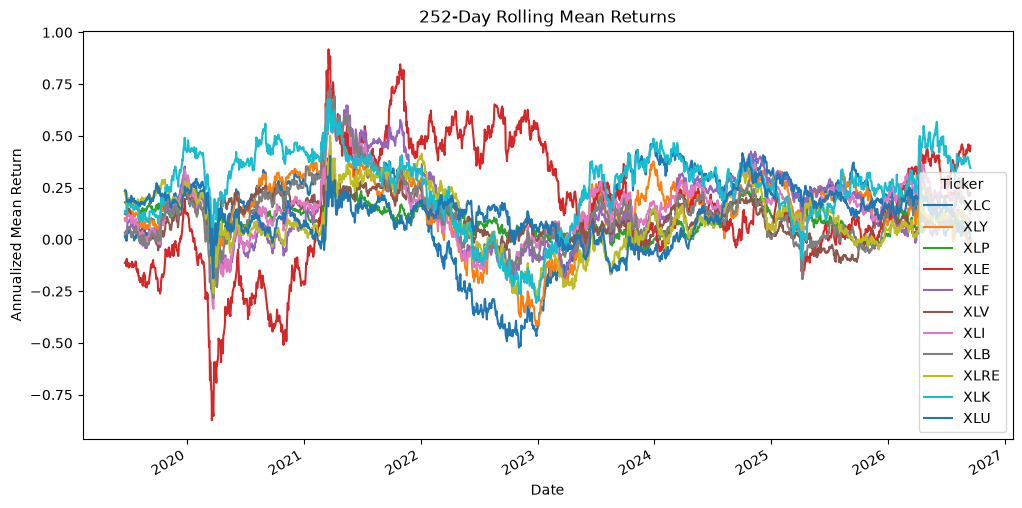

In [99]:
rolling_mu = df[sectors].rolling(252).mean() * 252

rolling_mu.plot(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Annualized Mean Return")
plt.title("252-Day Rolling Mean Returns")
plt.show()

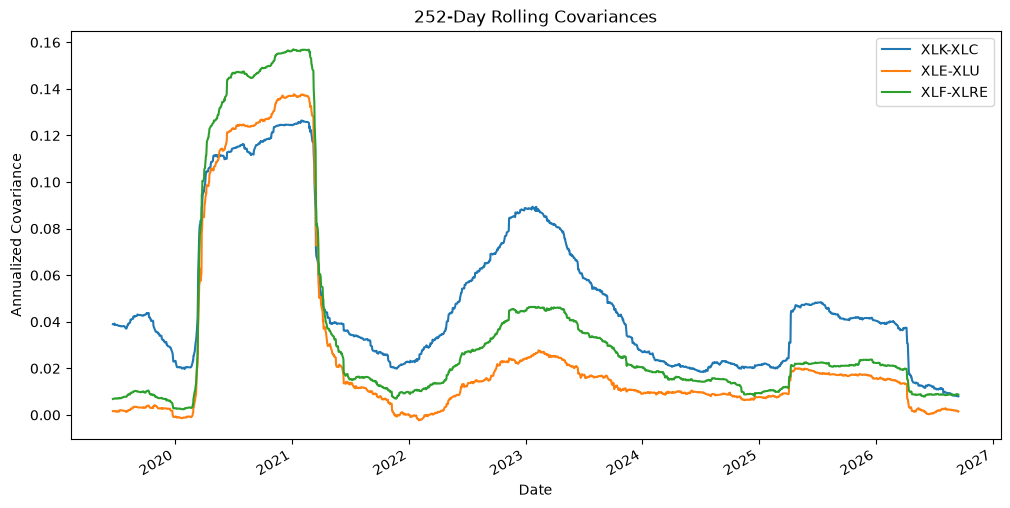

In [100]:
rolling_covs = pd.DataFrame({
    f"{a}-{b}":
        df[a].rolling(252).cov(df[b]) * 252
    for a, b in pairs
})

rolling_covs.plot(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Annualized Covariance")
plt.title("252-Day Rolling Covariances")
plt.show()

The bootstrap plots show that mean returns are still fairly uncertain, with the middle 50% of XLE’s annualized mean estimates ranging from about 8.4% to 23.5%, compared with 5.9% to 13.6% for XLP. The covariance estimates are more concentrated relative to their medians, but the rolling plots show that neither means nor covariances stay constant over time. XLE’s annualized rolling mean changes from roughly −87% in March 2020 to 92% in March 2021, while XLP varies less. All three plotted covariances rise substantially during 2020 and early 2021, showing periods where the sectors move together more strongly. I would say this makes the full-sample estimates less convincing as forecasts: the bootstrap measures uncertainty when resampling the same history, but the rolling plots show how much the estimates depend on which period we use.

### 2.4 — Dimension vs. Sample Size: When the Universe Outgrows the Data

Sections 2.1–2.3 held the universe fixed at 12 assets and varied how much *history* you had. But a PM can just as easily expand the *universe* — trading 50 or 200 individual names instead of 12 sector ETFs — without getting any more years of data to estimate with. This subsection asks the same question as 2.1 (how good is $\hat{\boldsymbol{\Sigma}}$?), but sweeps dimension $k$ instead of sample size $n$.

Fix the sample size at $n = 252$ (one trading year — a realistic amount of history for a newer strategy or a recently-listed set of names) for the entire subsection. You'll need a "ground truth" $\boldsymbol{\Sigma}^*(k)$ that scales to arbitrary $k$, since you only have 12 real assets to work with:

- For $k \leq 12$, you can use your real full-sample sector-ETF estimates (as in 2.1), subset to the first $k$ assets.
- For $k > 12$, construct a synthetic ground truth with the same one-factor structure as your CAPM estimates in 2.2: $\boldsymbol{\Sigma}^*(k) = \mathbf{D} + \boldsymbol{\beta}\boldsymbol{\beta}^\intercal \sigma_m^2$, where $\sigma_m^2$ is your estimated market (SPY) variance, and the $k$-vector $\boldsymbol{\beta}$ and diagonal idiosyncratic variances $\mathbf{D}$ are drawn to match the *empirical spread* of the betas and idiosyncratic variances you actually estimated for the 12 sector ETFs in 2.2 (e.g., sample from a distribution fit to those 12 real values, rather than inventing arbitrary numbers). Document this construction in a prose cell — the point isn't that this is a realistic 200-asset universe, it's that it's a $k$-asset ground truth grounded in real, estimated parameters.

For a grid of $k$ that spans well below, near, and **above** $n = 252$ (e.g., $k \in \{5, 12, 50, 150, 252, 400\}$), simulate many samples of size $n$ from $\mathcal{N}(\boldsymbol{\mu}^*(k), \boldsymbol{\Sigma}^*(k))$ and compute $\hat{\boldsymbol{\Sigma}}$ for each. Track, across simulations and as a function of $k$:

- The **condition number** of $\hat{\boldsymbol{\Sigma}}$ (ratio of largest to smallest eigenvalue) — a numerically well-behaved matrix has a modest condition number; a nearly-singular one has a huge one.
- The **smallest eigenvalue** of $\hat{\boldsymbol{\Sigma}}$ directly. What happens to it as $k$ approaches, and then exceeds, $n$? (Recall that a sample covariance matrix estimated from $n$ observations of $k$ variables is mathematically guaranteed to be singular once $k > n$ — this isn't a modeling failure, it's a hard fact about how many independent directions of variation $n$ data points can possibly pin down.)
- The magnitude of the resulting **unconstrained** $\mathbf{w}^*$ (e.g., its $L_2$ norm, or gross leverage $\sum_i|w_i|$) computed from each simulated $\hat{\boldsymbol{\Sigma}}$, at a fixed $\gamma$.

Produce a plot (or small panel of plots) showing all three quantities against $k$, on a log scale for $k$ if that helps readability. Write a paragraph connecting what you see to the closed-form $\mathbf{w}^* \propto \hat{\boldsymbol{\Sigma}}^{-1}\hat{\boldsymbol{\mu}}$: why does a near-singular (or literally singular) $\hat{\boldsymbol{\Sigma}}$ make the *inverse* — and therefore the weights — blow up numerically, even when the *true* $\boldsymbol{\Sigma}^*(k)$ is perfectly well-behaved at every $k$? This is the dimension-side counterpart to 2.1's sample-size finding, and it's the reason Section 3.5's constrained weights and (in industry) shrinkage estimators like Ledoit-Wolf exist — not required here, but worth knowing that "regularize $\hat{\boldsymbol{\Sigma}}$ before inverting it" is a standard professional response to exactly the failure mode you just produced.

In [ ]:
rng_dim = np.random.default_rng(RANDOM_SEED)

n_dim = 252
k_grid = [5, 12, 50, 150, 240, 250, 252, 400]
n_sim_dim = 200
gamma_dim = 5.0

# Fit synthetic daily means to the observed sector means.
real_means = df[sectors].mean()

mu_fake = rng_dim.normal(
    loc=real_means.mean(),
    scale=real_means.std(ddof=0),
    size=400
)

# Fit distributions to the sector CAPM estimates from section 2.2.
log_d = np.log(residual_vars)

synthetic_d = rng_dim.lognormal(
    mean=log_d.mean(),
    sigma=log_d.std(ddof=0),
    size=400
)

synthetic_beta = rng_dim.normal(
    loc=betas.mean(),
    scale=betas.std(ddof=0),
    size=400
)

# Construct the 400 × 400 ground-truth covariance matrix.
cov_fake = (
    np.diag(synthetic_d)
    + np.outer(synthetic_beta, synthetic_beta) * market_var
)

errors = defaultdict(list)
diagnostics = []

for k in k_grid:
    if k <= 12:
        real_returns = df[tickers[:k]]
        mu_true = real_returns.mean().to_numpy()
        cov_true = real_returns.cov().to_numpy()
    else:
        indices = rng_dim.choice(cov_fake.shape[0], size=k, replace=False)
        mu_true = mu_fake[indices]
        cov_true = cov_fake[np.ix_(indices, indices)]

    # Factor the fixed ground truth once per dimension.
    chol_true = np.linalg.cholesky(cov_true)
    true_weights = np.linalg.solve(cov_true, mu_true) / gamma_dim
    true_gross_leverage = np.abs(true_weights).sum()

    for _ in range(n_sim_dim):
        samples = mu_true + rng_dim.standard_normal((n_dim, k)) @ chol_true.T

        mu_hat = samples.mean(axis=0)
        cov_hat = np.cov(samples.T)

        eigenvalues = np.linalg.eigvalsh(cov_hat)
        # Centering n observations gives rank at most n - 1.
        tolerance = np.finfo(float).eps * k * eigenvalues[-1]
        singular = k >= n_dim or eigenvalues[0] <= tolerance
        min_eigenvalue = 0.0 if singular else eigenvalues[0]
        condition_number = np.inf if singular else eigenvalues[-1] / eigenvalues[0]

        error_mu = np.sqrt(np.mean((mu_hat - mu_true) ** 2))
        error_cov = np.linalg.norm(cov_hat - cov_true, "fro")

        # A singular sample matrix has no ordinary inverse-based optimum.
        if singular:
            gross_leverage = np.nan
        else:
            weights = np.linalg.solve(cov_hat, mu_hat) / gamma_dim
            gross_leverage = np.abs(weights).sum()

        leverage_ratio = gross_leverage / true_gross_leverage

        diagnostics.append({
            "k": k,
            "condition_number": condition_number,
            "min_eigenvalue": min_eigenvalue,
            "gross_leverage": gross_leverage,
            "true_gross_leverage": true_gross_leverage,
            "leverage_ratio": gross_leverage / true_gross_leverage,
        })

        errors[k].append((error_mu, error_cov, min_eigenvalue, condition_number, leverage_ratio))

    errors[k] = {
        "error_mu": np.mean([error[0] for error in errors[k]]),
        "error_cov": np.mean([error[1] for error in errors[k]]),
        "min_eigenvalue": np.mean([error[2] for error in errors[k]]),
        "condition_number": np.mean([error[3] for error in errors[k]]),
        "leverage_ratio": np.mean([error[4] for error in errors[k]])
    }

errors
diagnostics_df = pd.DataFrame(diagnostics)

diagnostic_summary = diagnostics_df.groupby("k").median()
diagnostic_summary


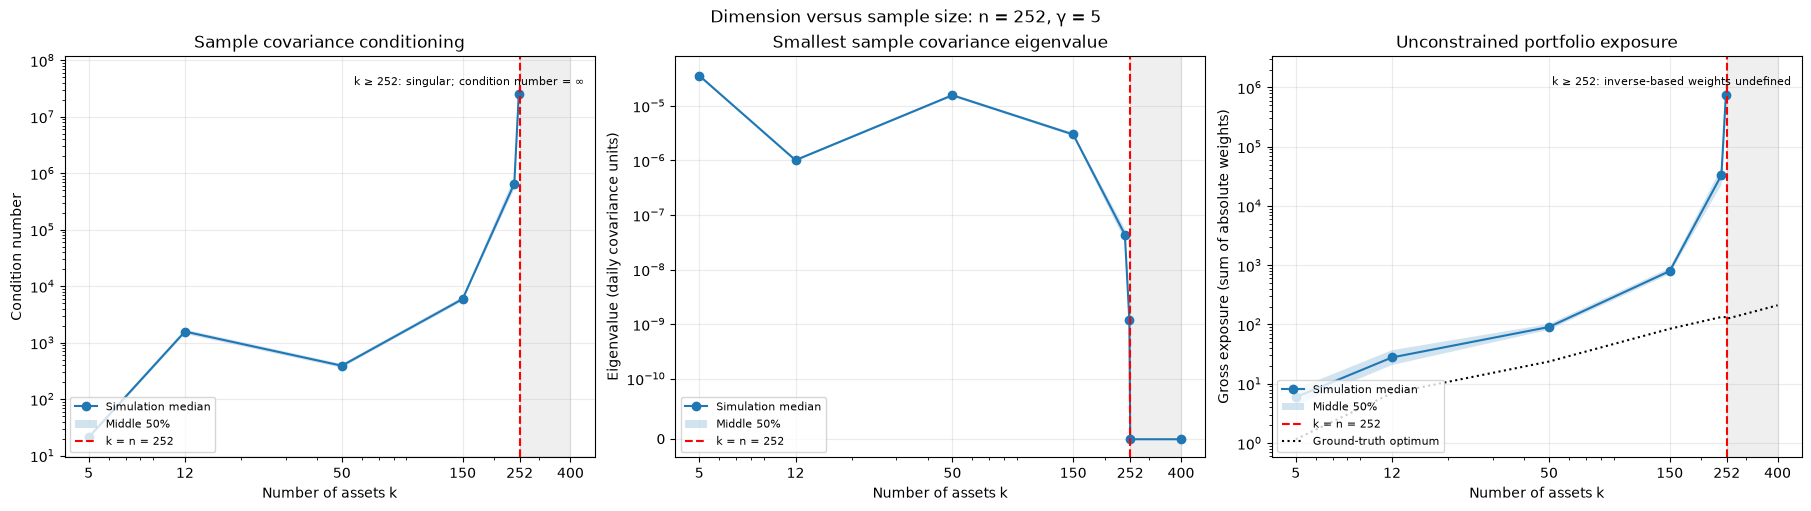

In [ ]:
# Show medians and the middle 50% across the 200 simulations.
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
metrics_dim = [
    ("condition_number", "Sample covariance conditioning", "Condition number", "log"),
    ("min_eigenvalue", "Smallest sample covariance eigenvalue", "Eigenvalue (daily covariance units)", "symlog"),
    ("gross_leverage", "Unconstrained portfolio exposure", "Gross exposure (sum of absolute weights)", "log"),
]

for ax, (metric, title, ylabel, scale) in zip(axes, metrics_dim):
    values = diagnostics_df.replace([np.inf, -np.inf], np.nan)
    grouped = values.groupby("k")[metric]
    median = grouped.median()
    lower = grouped.quantile(0.25)
    upper = grouped.quantile(0.75)
    ax.plot(median.index, median, marker="o", label="Simulation median")
    ax.fill_between(median.index, lower, upper, alpha=0.2, label="Middle 50%")
    if scale == "symlog":
        ax.set_yscale("symlog", linthresh=1e-10)
    else:
        ax.set_yscale(scale)
    ax.set_xscale("log")
    ax.set_xticks([5, 12, 50, 150, 252, 400])
    ax.set_xticklabels([5, 12, 50, 150, 252, 400])
    ax.axvline(n_dim, color="red", linestyle="--", label="k = n = 252")
    ax.axvspan(n_dim, max(k_grid), color="gray", alpha=0.12)
    ax.set_title(title)
    ax.set_xlabel("Number of assets k")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)

axes[0].text(0.98, 0.95, "k ≥ 252: singular; condition number = ∞",
             transform=axes[0].transAxes, ha="right", va="top", fontsize=8)
axes[2].text(0.98, 0.95, "k ≥ 252: inverse-based weights undefined",
             transform=axes[2].transAxes, ha="right", va="top", fontsize=8)
axes[2].plot(
    diagnostic_summary.index, diagnostic_summary["true_gross_leverage"],
    linestyle=":", color="black", label="Ground-truth optimum",
)
for ax in axes:
    ax.legend(fontsize=8, loc="lower left")
fig.suptitle(f"Dimension versus sample size: n = {n_dim}, γ = {gamma_dim:g}")
plt.show()


The shaded bands show the middle 50% of simulations. The smallest-eigenvalue panel uses a symmetric-log scale so zero remains visible; the other panels use log scales. With 252 observations, centering limits sample covariance rank to 251, so matrices are singular at k = 252 and above. Those cases have infinite condition numbers and undefined ordinary inverse-based weights, rather than meaningful negative condition numbers or extremely large computed positions. The dotted exposure curve uses the true means and covariance as a reference.

## Section 3 — How Uncertainty in Parameters Propagates to Weights

*In practice: this is a sensitivity / stress-testing exercise — the kind of analysis a risk team runs on any model before it's approved, and the kind of question a PM will ask you the moment you present a portfolio: "how fragile is this?"*

The quantities $\boldsymbol{\mu}$ and $\boldsymbol{\Sigma}$ are not directly observable in a portfolio — the observable outcome is the weight vector $\mathbf{w}^*$. This section asks you to understand *how sensitive* $\mathbf{w}^*$ is to its inputs.

Use a fixed base estimate (e.g., your CAPM or sample-moment estimates from Section 2 on the full training window) as the reference $\hat{\boldsymbol{\mu}}$ and $\hat{\boldsymbol{\Sigma}}$.

### 3.1 — Sensitivity to $\gamma$

Compute $\mathbf{w}^*(\gamma)$ for a grid of risk-aversion values, say $\gamma \in [0.1,\, 20]$ on a log scale. For each $\gamma$, record the full weight vector. Produce a plot that shows how each sector's weight evolves across this range. What are the extreme cases? At what $\gamma$ does the portfolio become "reasonable" (no extreme allocations)?

In [ ]:
split = int(len(df) * 0.6)
train_returns = df.iloc[:split][sectors]

mu_base = train_returns.mean().to_numpy()
cov_base = train_returns.cov().to_numpy()

rf = 0.0
gamma_base = 5.0

def optimal_weights(mu, cov, gamma):
    return np.linalg.solve(cov, mu - rf) / gamma

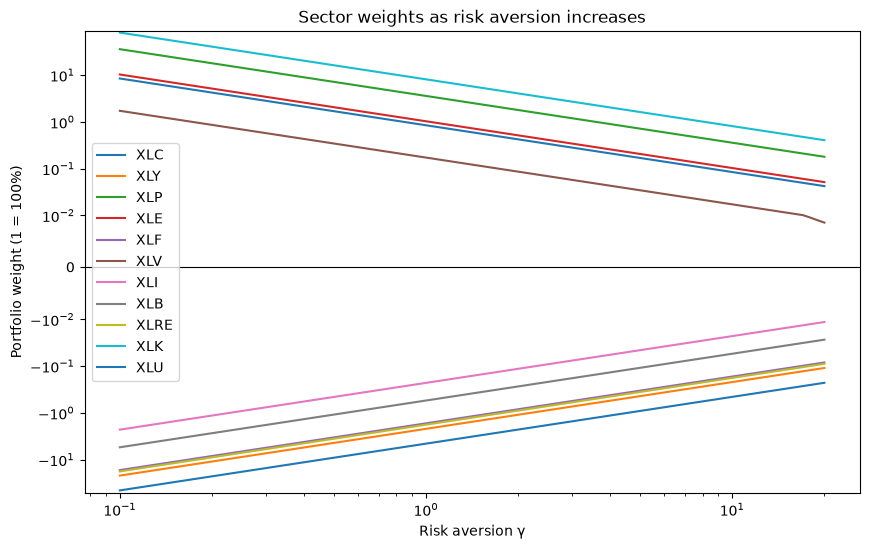

In [ ]:
gamma_grid = np.geomspace(0.1, 20, 100)

weights_gamma = pd.DataFrame(
    [
        optimal_weights(mu_base, cov_base, gamma)
        for gamma in gamma_grid
    ],
    index=gamma_grid,
    columns=sectors
)

ax = weights_gamma.plot(figsize=(10, 6))
ax.set_xscale("log")
ax.set_yscale("symlog", linthresh=0.01)
ax.set_xlabel("Risk aversion γ")
ax.set_ylabel("Portfolio weight (1 = 100%)")
ax.set_title("Sector weights as risk aversion increases")
ax.axhline(0, color="black", linewidth=0.8)
plt.show()

In [ ]:
weight_sizes = pd.DataFrame({
    "Largest absolute weight": weights_gamma.abs().max(axis=1),
    "Gross leverage": weights_gamma.abs().sum(axis=1),
})

weight_sizes.loc[
    [weights_gamma.index[np.abs(weights_gamma.index - g).argmin()]
     for g in [1, 5, 10]]
]

,Largest absolute weight,Gross leverage
0.998705,8.122429,24.767250
4.974152,1.630813,4.972742
9.974119,0.813296,2.479936


I would say a risk aversion of around 10 gives more reasonable individual positions, with the largest absolute weight around 0.81, although gross leverage is still about 2.47. If we also require gross leverage of at most 2, the first tested gamma meeting both criteria is about 13.03. Low gamma values produce extreme long and short positions, while increasing gamma scales all positions down without changing their relative composition.


### 3.2 — Sensitivity to $\boldsymbol{\mu}$

Starting from the base $\hat{\boldsymbol{\mu}}$, explore what happens as you move it toward zero. Specifically, define the family
$$
\boldsymbol{\mu}(\alpha) = (1 - \alpha)\,\hat{\boldsymbol{\mu}}, \qquad \alpha \in [0, 1].
$$
At $\alpha = 0$ you have the estimated means; at $\alpha = 1$ all means are zero. Compute $\mathbf{w}^*$ along this path (fixing $\hat{\boldsymbol{\Sigma}}$ and a chosen $\gamma$) and visualize how the weights evolve. At what value of $\alpha$ do the weights become "well-behaved"?


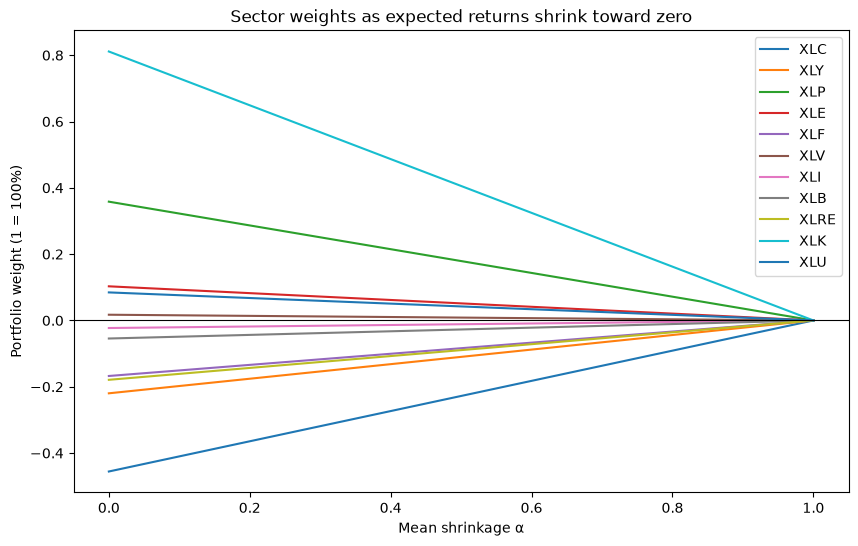

In [ ]:
gamma_base = 10.0
alpha_grid = np.linspace(0, 1, 101)

weights_alpha = pd.DataFrame(
    [
        optimal_weights((1 - alpha) * mu_base, cov_base, gamma_base)
        for alpha in alpha_grid
    ],
    index=alpha_grid,
    columns=sectors
)

ax = weights_alpha.plot(figsize=(10, 6))
ax.set_xlabel("Mean shrinkage α")
ax.set_ylabel("Portfolio weight (1 = 100%)")
ax.set_title("Sector weights as expected returns shrink toward zero")
ax.axhline(0, color="black", linewidth=0.8)
plt.show()

In [ ]:
alpha_summary = pd.DataFrame({
    "Largest absolute weight": weights_alpha.abs().max(axis=1),
    "Gross leverage": weights_alpha.abs().sum(axis=1),
})

reasonable = (
    (alpha_summary["Largest absolute weight"] < 1)
    & (alpha_summary["Gross leverage"] <= 2)
)

if reasonable.any():
    first_alpha = alpha_summary.index[reasonable][0]
    print(f"First tested alpha meeting both criteria: {first_alpha:.2f}")

First tested alpha meeting both criteria: 0.20


Given reasonable criteria of a maximum absolute weight below 1 and gross leverage at most 2, the first tested alpha we could consider is 0.20 with gamma fixed at 10. Shrinking the means scales each weight by (1 - alpha), reducing gross leverage from about 2.47 to 1.98 at this point. The relative composition stays unchanged until alpha reaches 1, when all weights are zero.

### 3.3 — Sensitivity to Correlations

To inflate or deflate correlations while keeping the matrix positive definite and the variances unchanged, you need to work with the **correlation matrix**. Decompose:
$$
\boldsymbol{\Sigma} = \mathbf{D}\,\mathbf{C}\,\mathbf{D},
$$
where $\mathbf{D} = \text{diag}(\sigma_1, \ldots, \sigma_k)$ is the diagonal matrix of standard deviations and $\mathbf{C}$ is the correlation matrix. Define the perturbed correlation matrix
$$
\mathbf{C}(\rho) = (1 - \rho)\,\mathbf{C} + \rho\,\mathbf{1}\mathbf{1}^\intercal / k, \qquad \rho \in [0, 1),
$$
(or another reasonable perturbation of your choice) and reconstruct $\boldsymbol{\Sigma}(\rho) = \mathbf{D}\,\mathbf{C}(\rho)\,\mathbf{D}$. Compute $\mathbf{w}^*$ across values of $\rho$ and visualize. What is the intuition for what happens as all assets become more correlated?

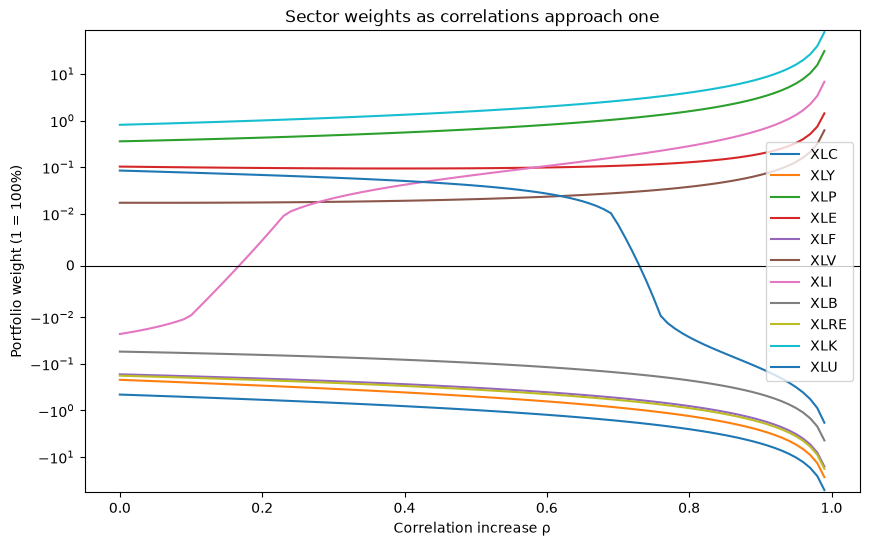

In [ ]:
# Separate baseline volatility from correlation.
std_base = np.sqrt(np.diag(cov_base))
D = np.diag(std_base)
corr_base = cov_base / np.outer(std_base, std_base)

rho_grid = np.linspace(0, 0.99, 100)
weights_rho = []

for rho in rho_grid:
    corr_rho = (
        (1 - rho) * corr_base
        + rho * np.ones_like(corr_base)
    )
    cov_rho = D @ corr_rho @ D

    # Verify that variances stay fixed and covariance stays positive definite.
    assert np.allclose(np.diag(cov_rho), np.diag(cov_base))
    assert np.linalg.eigvalsh(cov_rho)[0] > 0

    weights_rho.append(
        optimal_weights(mu_base, cov_rho, gamma_base)
    )

weights_rho = pd.DataFrame(
    weights_rho,
    index=rho_grid,
    columns=sectors
)

ax = weights_rho.plot(figsize=(10, 6))
ax.set_yscale("symlog", linthresh=0.01)
ax.set_xlabel("Correlation increase ρ")
ax.set_ylabel("Portfolio weight (1 = 100%)")
ax.set_title("Sector weights as correlations approach one")
ax.axhline(0, color="black", linewidth=0.8)
plt.show()

As correlations approach one, the absolute portfolio weights increase sharply. Highly correlated assets allow offsetting long and short positions to appear to have very little risk under the model, so the unconstrained optimizer takes increasingly large positions. I would interpret this as instability as the covariance matrix approaches singularity, rather than evidence that the larger allocations are safe. Interestingly, XLI changes from a short to a long position, while XLC remains short and its position grows in magnitude. I used an all-ones correlation target without dividing by k so that individual variances remain unchanged.

### 3.4 — Sensitivity to Volatility

Using the same decomposition $\boldsymbol{\Sigma} = \mathbf{D}\,\mathbf{C}\,\mathbf{D}$, define the scaled covariance matrix
$$
\boldsymbol{\Sigma}(s) = (s\,\mathbf{D})\,\mathbf{C}\,(s\,\mathbf{D}), \qquad s > 0,
$$
which scales all standard deviations by $s$ while preserving all pairwise correlations. Compute $\mathbf{w}^*$ across values of $s \in [0.5, 3]$ and visualize. Does scaling volatility up or down change the *composition* of the portfolio or just the implied risk?

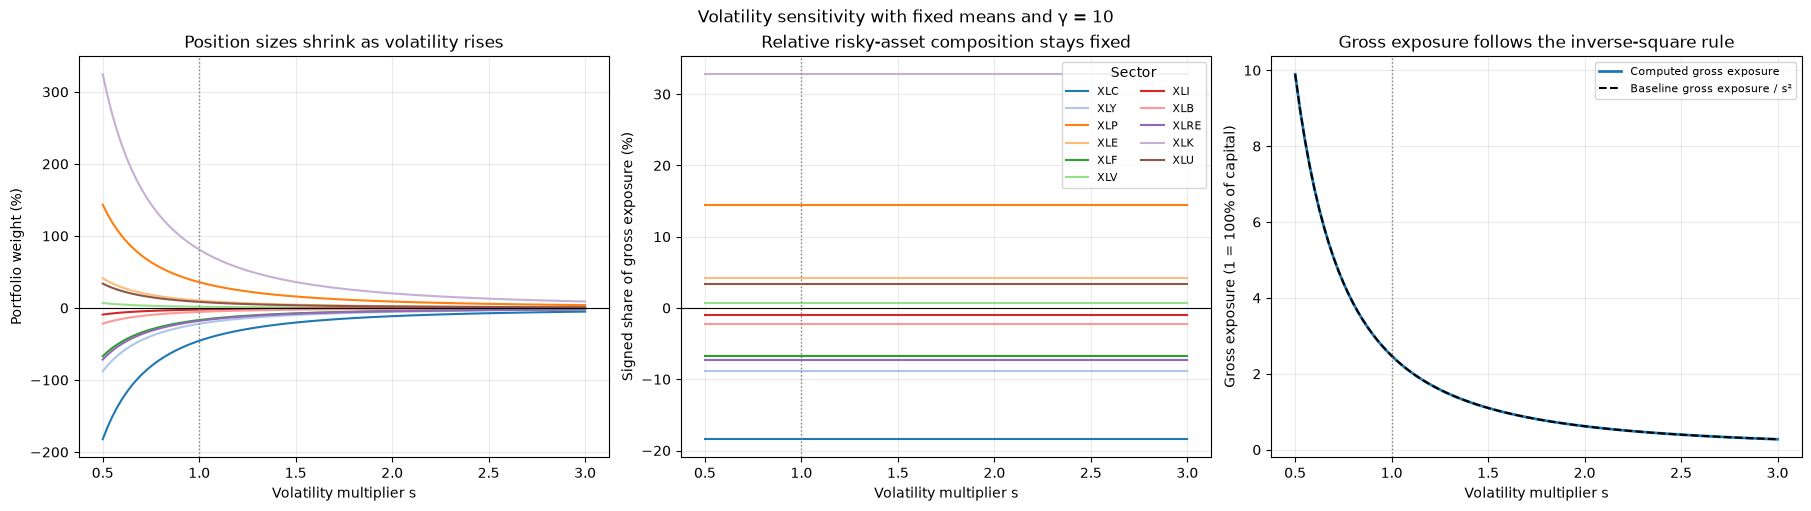

In [ ]:
s_grid = np.linspace(0.5, 3.0, 101)

weights_s = pd.DataFrame(
    [optimal_weights(mu_base, s**2 * cov_base, gamma_base) for s in s_grid],
    index=s_grid,
    columns=sectors,
)

# Normalize by gross exposure to compare composition while retaining short signs.
gross_exposure_s = weights_s.abs().sum(axis=1)
composition_s = weights_s.div(gross_exposure_s, axis=0)
baseline_weights_s = optimal_weights(mu_base, cov_base, gamma_base)
baseline_gross_s = np.abs(baseline_weights_s).sum()

# Uniform volatility scaling should scale every unconstrained position by 1/s².
assert np.allclose(
    weights_s.to_numpy(), baseline_weights_s[None, :] / s_grid[:, None]**2
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
colors = plt.get_cmap("tab20").colors[:len(sectors)]

(weights_s * 100).plot(ax=axes[0], color=colors, legend=False)
axes[0].set_title("Position sizes shrink as volatility rises")
axes[0].set_ylabel("Portfolio weight (%)")
axes[0].axhline(0, color="black", linewidth=0.8)

(composition_s * 100).plot(ax=axes[1], color=colors)
axes[1].set_title("Relative risky-asset composition stays fixed")
axes[1].set_ylabel("Signed share of gross exposure (%)")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].legend(title="Sector", ncol=2, fontsize=8)

axes[2].plot(s_grid, gross_exposure_s, label="Computed gross exposure", linewidth=2)
axes[2].plot(
    s_grid, baseline_gross_s / s_grid**2,
    linestyle="--", color="black", label="Baseline gross exposure / s²",
)
axes[2].set_title("Gross exposure follows the inverse-square rule")
axes[2].set_ylabel("Gross exposure (1 = 100% of capital)")
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel("Volatility multiplier s")
    ax.axvline(1, color="gray", linestyle=":", linewidth=1)
    ax.grid(alpha=0.25)

fig.suptitle(f"Volatility sensitivity with fixed means and γ = {gamma_base:g}")
plt.show()


As volatility increases, each asset carries more risk per dollar invested, leading to smaller portfolio weights while the relative composition remains unchanged. The weights scale by 1/s^2, so doubling volatility quarters every position and total gross exposure. The flat lines in the composition plot show that this changes the size of the positions rather than the relative mix of sectors.

### 3.5 — A Dose of Realism: Constrained Weights

The closed-form $\mathbf{w}^*$ you've been computing is unconstrained — it is free to short assets and to take arbitrarily large positions. Real mandates almost always impose some constraint on top of the mean-variance objective, though which constraint depends a lot on the fund. A few common ones:

- **Long-only** ($w_i \geq 0$): common for retail-facing funds and many institutional mandates, but plenty of funds (long/short equity, market-neutral, macro) short freely — this is a mandate choice, not a law of nature.
- **Position cap** (e.g., $w_i \leq 0.25$): limits concentration in any single name or sector.
- **Leverage constraint** ($\sum_i |w_i| \leq L$ for some $L$, e.g. $L=1$ for no leverage or $L=2$ for 2-to-1 gross leverage): caps total gross exposure regardless of the long/short split — this is how many hedge funds actually bound risk instead of (or in addition to) going long-only.

Pick **one or two constraints from this list (or a reasonable variant of your own)** that you find most interesting, and re-solve for $\mathbf{w}^*$ under them using your base $\hat{\boldsymbol{\mu}}$ and $\hat{\boldsymbol{\Sigma}}$ from Section 2. You will need a numerical solver rather than the closed-form formula — `scipy.optimize.minimize` (SLSQP) or `cvxpy` both work well for this (note the leverage constraint is not smooth as written; either reformulate it for your solver or pick a smooth relaxation). Compare the constrained weights to the unconstrained weights from earlier in Section 3: what changed, and how much expected utility (in the mean-variance objective) is "given up" by imposing the constraint(s) you chose?

In [ ]:
from scipy.optimize import minimize

leverage_cap = 1.0

# Use the original baseline inputs, not the perturbed covariance from 3.4.
def portfolio_utility(w):
    return (
        w @ (mu_base - rf)
        - (gamma_base / 2) * w @ cov_base @ w
    )

unconstrained_weights = optimal_weights(
    mu_base, cov_base, gamma_base
)

result = minimize(
    fun=lambda w: -portfolio_utility(w),
    x0=np.zeros(len(sectors)),
    jac=lambda w: gamma_base * cov_base @ w - (mu_base - rf),
    method="SLSQP",
    bounds=[(0, None)] * len(sectors),
    constraints=[{
        "type": "ineq",
        "fun": lambda w: leverage_cap - w.sum(),
        "jac": lambda w: -np.ones_like(w),
    }],
    options={"ftol": 1e-12, "maxiter": 1000},
)

constrained_weights = result.x

,Unconstrained,"Long-only, leverage ≤ 1"
XLC,-0.455625,0.000000e+00
XLY,-0.219787,0.000000e+00
XLP,0.358243,1.599575e-01
XLE,0.102929,7.722441e-18
XLF,-0.167535,3.195981e-18
XLV,0.017224,4.083537e-19
XLI,-0.022864,0.000000e+00
XLB,-0.054495,0.000000e+00
XLRE,-0.179075,0.000000e+00
XLK,0.811191,2.060730e-01


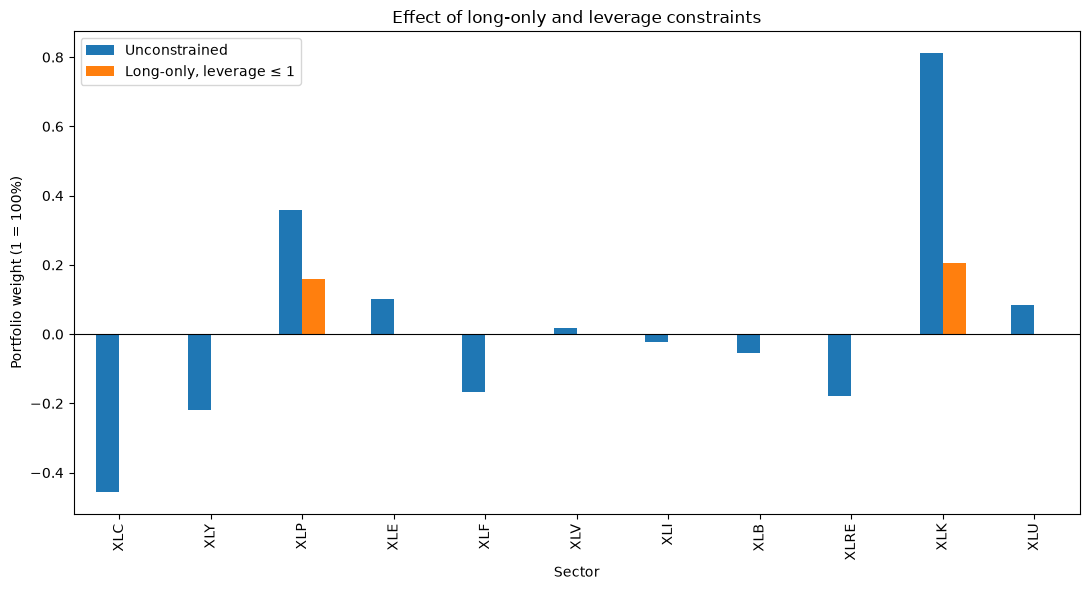

,Unconstrained,Constrained
Gross leverage,2.473518,0.366031
Daily mean-variance utility,0.000282,0.000124


Daily utility given up: 0.00015859


In [ ]:
weight_comparison = pd.DataFrame({
    "Unconstrained": unconstrained_weights,
    "Long-only, leverage ≤ 1": constrained_weights,
}, index=sectors)

display(weight_comparison)

ax = weight_comparison.plot.bar(figsize=(11, 6))
ax.set_xlabel("Sector")
ax.set_ylabel("Portfolio weight (1 = 100%)")
ax.set_title("Effect of long-only and leverage constraints")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

utility_unconstrained = portfolio_utility(unconstrained_weights)
utility_constrained = portfolio_utility(constrained_weights)

display(pd.DataFrame({
    "Unconstrained": [
        np.abs(unconstrained_weights).sum(),
        utility_unconstrained,
    ],
    "Constrained": [
        np.abs(constrained_weights).sum(),
        utility_constrained,
    ],
}, index=["Gross leverage", "Daily mean-variance utility"]))

print(
    "Daily utility given up:",
    f"{utility_unconstrained - utility_constrained:.8f}"
)

With a leverage cap of 1 and long-only positions, the optimizer allocates only to XLK and XLP, at about 20.6% and 16.0%; the other weights are effectively zero. This contrasts with the unconstrained portfolio's larger positions in both sectors and its offsetting short positions. Gross exposure falls from about 2.47 to 0.37, so the leverage cap is not binding here; the long-only restriction drives the change. The portfolio is still concentrated in two sectors. Daily mean-variance utility decreases from about 0.000282 to 0.000124, giving up approximately 0.00015859.

## Section 4 — The Effect of Rebalancing and Trading Costs

*In practice: this is implementation shortfall — the gap between a paper strategy and a tradeable one. It's often the difference between a strategy that gets funded and one that doesn't.*

Sections 2 and 3 were about the inputs. This section is about what happens when we actually use $\mathbf{w}^*$ in practice.

**Train/test split**: use the first 60% of your data as the training period (estimate parameters here) and the remaining 40% as the test period (evaluate performance here). Never use test data to make portfolio decisions.

**Benchmarks**: in every comparison below, include two passive benchmarks:
- **Equal-weight (EW)**: $\mathbf{w} = \mathbf{1}/k$ held fixed and rebalanced each period.
- **SPY**: the market ETF return series.


In [ ]:
# Chronological split—never shuffle time-series data.
split = int(len(df) * 0.6)
train_data = df.iloc[:split].copy()
test_data = df.iloc[split:].copy()

# Estimate portfolio inputs using training data only.
mu_train = train_data[sectors].mean().to_numpy()
cov_train = train_data[sectors].cov().to_numpy()

# Keep the same risk-aversion choice as section 3.
weights_model = optimal_weights(mu_train, cov_train, gamma_base)

# Equal-weight across the 11 sectors; SPY is a separate benchmark.
weights_ew = np.ones(len(sectors)) / len(sectors)

# Daily rebalanced, frictionless benchmark returns for section 4.1.
benchmark_returns = pd.DataFrame({
    "Equal-weight": test_data[sectors] @ weights_ew,
    "SPY": test_data["SPY"],
})

display(pd.DataFrame({
    "Start": [train_data.index.min(), test_data.index.min()],
    "End": [train_data.index.max(), test_data.index.max()],
    "Trading days": [len(train_data), len(test_data)],
}, index=["Training", "Testing"]))

,Start,End,Trading days
Training,2018-06-20,2023-05-25,1242
Testing,2023-05-26,2026-09-15,828


### 4.1 — Frictionless Rebalancing

Assume you can trade at zero cost. At the start of the test period, invest according to $\mathbf{w}^*$ computed on the training data. Rebalance back to $\mathbf{w}^*$ every trading day (i.e., $\mathbf{w}$ is held constant throughout the test period).

Report and plot:

- Cumulative return over the test period (log scale optional)
- Annualized Sharpe ratio (use the risk-free rate from one of your data sources, or set it to zero and note that)
- Maximum drawdown
- Annualized volatility

How do your model-based portfolios compare to the benchmarks?

In [ ]:
# Each row contains the return earned using fixed target weights.
returns_41 = benchmark_returns.copy()
returns_41.insert(
    0, "Model",
    test_data[sectors] @ weights_model
)

# rf = 0: any cash balance or borrowing has zero interest in this model.
wealth_41 = (1 + returns_41).cumprod()

# Include initial wealth of 1 when calculating running peaks.
running_peak = wealth_41.cummax().clip(lower=1.0)
drawdown_41 = wealth_41 / running_peak - 1

daily_std = returns_41.std(ddof=1)

metrics_41 = pd.DataFrame({
    "Cumulative return": wealth_41.iloc[-1] - 1,
    "Annualized Sharpe": (
        returns_41.mean() / daily_std.replace(0, np.nan)
    ) * np.sqrt(252),
    "Maximum drawdown": drawdown_41.min(),
    "Annualized volatility": daily_std * np.sqrt(252),
})

display(metrics_41.style.format({
    "Cumulative return": "{:.2%}",
    "Annualized Sharpe": "{:.2f}",
    "Maximum drawdown": "{:.2%}",
    "Annualized volatility": "{:.2%}",
}))

,Cumulative return,Annualized Sharpe,Maximum drawdown,Annualized volatility
Model,33.88%,0.69,-19.07%,14.31%
Equal-weight,67.16%,1.35,-15.30%,12.16%
SPY,90.30%,1.38,-18.76%,14.95%


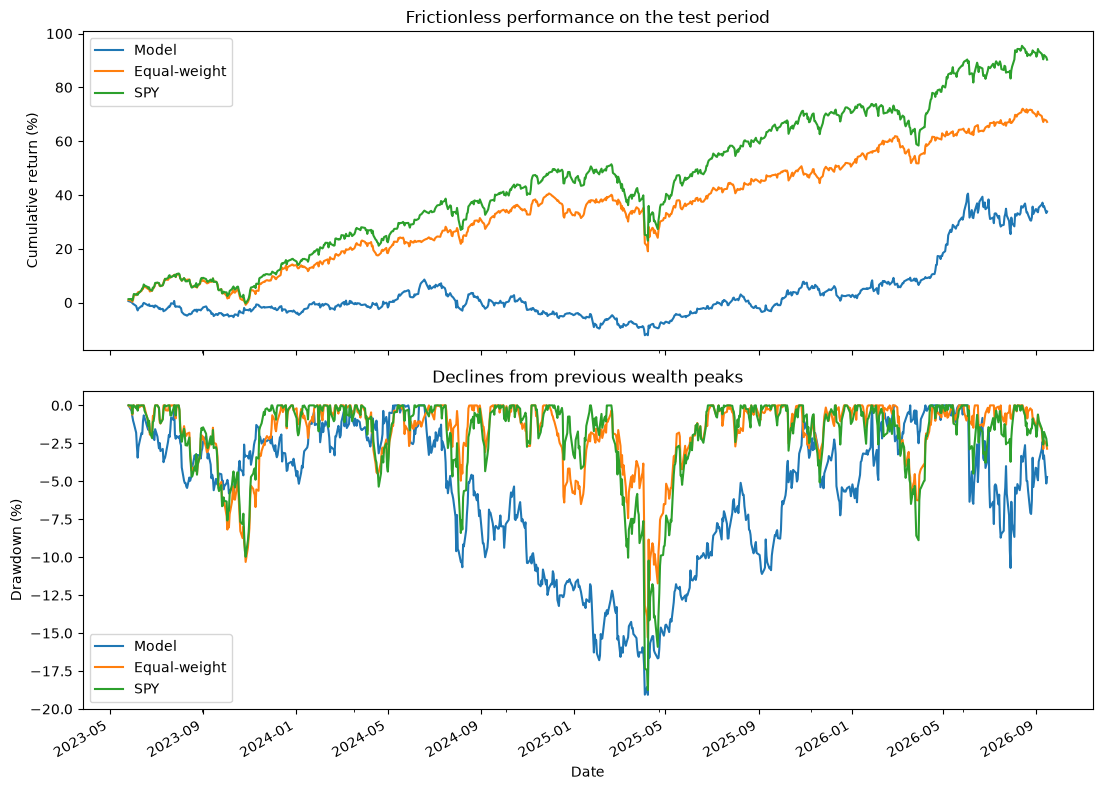

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

((wealth_41 - 1) * 100).plot(ax=axes[0])
axes[0].set_title("Frictionless performance on the test period")
axes[0].set_ylabel("Cumulative return (%)")

(drawdown_41 * 100).plot(ax=axes[1])
axes[1].set_title("Declines from previous wealth peaks")
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

The model portfolio underperforms both equal-weight and SPY on cumulative return. SPY also has the highest annualized Sharpe ratio, indicating better return per unit of volatility than either alternative. The model’s maximum drawdown is comparable to those of the benchmarks, so its lower return does not come with a substantial improvement in downside protection over this test period.

### 4.2 — Introducing Transaction Costs

Now make the simulation more realistic. At each rebalancing event, you must buy and sell assets to restore the target weights. Each dollar of turnover incurs a cost of $c$ (expressed in basis points, where $1\,\text{bp} = 0.0001$). The turnover at time $t$ is:
$$
\text{turnover}_t = \sum_{i=1}^k \lvert w_{t,i}^{\text{target}} - w_{t,i}^{\text{drifted}} \rvert
$$
where $w_{t,i}^{\text{drifted}}$ is the weight in asset $i$ just *before* rebalancing, after price changes have moved the portfolio away from the target. The cost is deducted from the portfolio value before applying the next period's returns.

Additionally, model a fixed **management fee** of $f$ basis points per year, deducted as a daily haircut: $r_{\text{net},t} = r_t - f/252$.

Investigate performance as a function of:

- Rebalancing frequency (daily, weekly, monthly, quarterly)
- Cost level $c$ (try a few values in the range 1–20 bps)

Produce at least one plot of net-of-cost annualized Sharpe ratio as a function of rebalancing frequency and cost level. What rebalancing frequency is approximately optimal? Does the answer depend on $c$?

In [ ]:
def backtest_costs(asset_returns, target_weights,
                   frequency="monthly", cost_bps=5, fee_bps=50):
    target = np.asarray(target_weights, dtype=float)
    c = cost_bps / 10_000
    daily_fee = fee_bps / 10_000 / 252

    # Rebalance on the first available trading day of each period.
    period_codes = {
        "daily": "D",
        "weekly": "W-FRI",
        "monthly": "M",
        "quarterly": "Q",
    }
    periods = asset_returns.index.to_period(period_codes[frequency])
    rebalance = np.r_[True, periods[1:] != periods[:-1]]

    # Start with all capital in cash; charge for the initial allocation.
    drifted = np.zeros_like(target)
    records = []

    for date, daily_returns, trade_today in zip(
        asset_returns.index, asset_returns.to_numpy(), rebalance
    ):
        turnover = 0.0

        if trade_today:
            turnover = np.abs(target - drifted).sum()
            held_weights = target.copy()
        else:
            held_weights = drifted.copy()

        cost_fraction = c * turnover
        if cost_fraction >= 1:
            raise ValueError("Trading costs exhaust portfolio capital.")

        gross_return = held_weights @ daily_returns

        # Trading cost first, then return, then management-fee haircut.
        net_growth = (
            (1 - cost_fraction) * (1 + gross_return)
            - daily_fee
        )

        if net_growth <= 0:
            raise ValueError("Portfolio equity has fallen to zero or below.")

        # Fees are funded from cash. Risky holdings evolve with asset returns.
        drifted = (
            (1 - cost_fraction)
            * held_weights
            * (1 + daily_returns)
            / net_growth
        )

        records.append({
            "Net return": net_growth - 1,
            "Turnover": turnover,
            "Trading cost fraction": cost_fraction,
        })

    return pd.DataFrame(records, index=asset_returns.index)

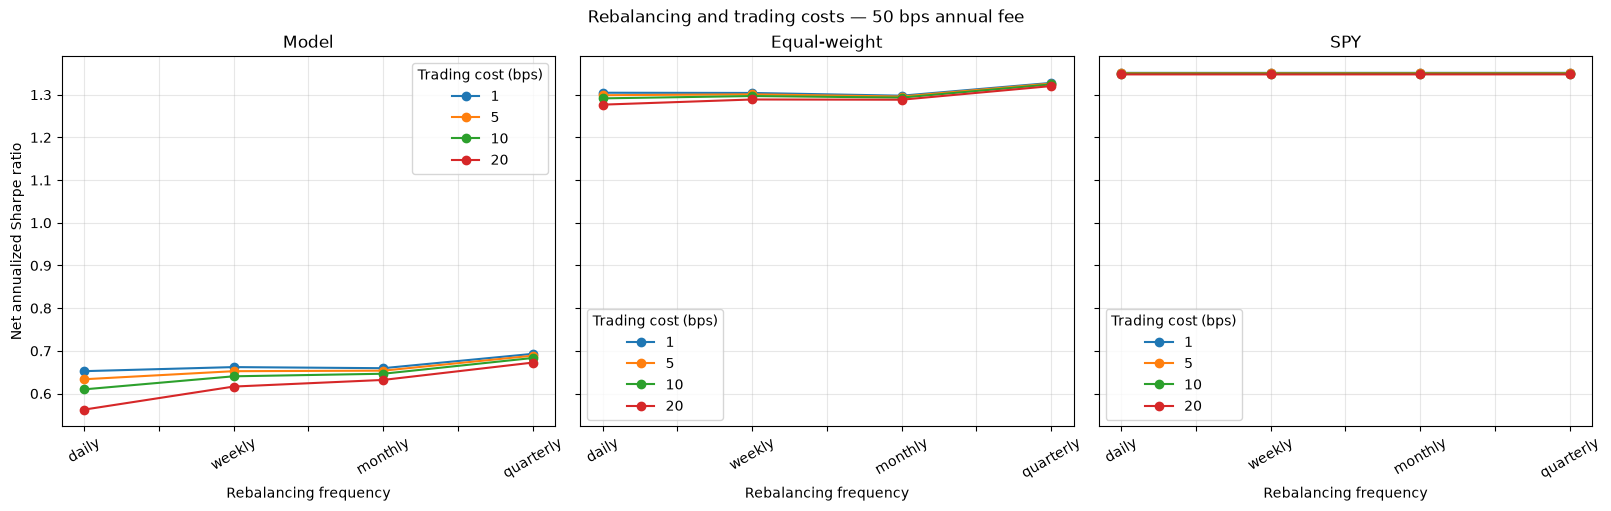

,Portfolio,Frequency,Cost (bps),Net Sharpe
0,Equal-weight,quarterly,1,1.327718
1,Equal-weight,quarterly,5,1.326160
2,Equal-weight,quarterly,10,1.324206
3,Equal-weight,quarterly,20,1.320275
4,Model,quarterly,1,0.692971
5,Model,quarterly,5,0.688682
6,Model,quarterly,10,0.683306
7,Model,quarterly,20,0.672509
8,SPY,quarterly,1,1.351243
9,SPY,quarterly,5,1.350494


In [ ]:
frequencies = ["daily", "weekly", "monthly", "quarterly"]
cost_levels = [1, 5, 10, 20]
management_fee_bps = 50

portfolios = {
    "Model": (test_data[sectors], weights_model),
    "Equal-weight": (test_data[sectors], weights_ew),
    "SPY": (test_data[["SPY"]], np.array([1.0])),
}

results_42 = []

for name, (asset_returns, target) in portfolios.items():
    for frequency in frequencies:
        for cost_bps in cost_levels:
            run = backtest_costs(
                asset_returns,
                target,
                frequency=frequency,
                cost_bps=cost_bps,
                fee_bps=management_fee_bps,
            )

            net_returns = run["Net return"]
            volatility = net_returns.std(ddof=1)
            sharpe = (
                net_returns.mean() / volatility * np.sqrt(252)
                if volatility > 0 else np.nan
            )

            results_42.append({
                "Portfolio": name,
                "Frequency": frequency,
                "Cost (bps)": cost_bps,
                "Net Sharpe": sharpe,
            })

results_42 = pd.DataFrame(results_42)

fig, axes = plt.subplots(
    1, 3, figsize=(16, 5), sharey=True, constrained_layout=True
)

for ax, name in zip(axes, portfolios):
    table = (
        results_42[results_42["Portfolio"] == name]
        .pivot(
            index="Frequency",
            columns="Cost (bps)",
            values="Net Sharpe",
        )
        .reindex(frequencies)
    )

    table.plot(ax=ax, marker="o")
    ax.set_title(name)
    ax.set_xlabel("Rebalancing frequency")
    ax.set_ylabel("Net annualized Sharpe ratio")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(alpha=0.3)
    ax.legend(title="Trading cost (bps)")

fig.suptitle(
    f"Rebalancing and trading costs — {management_fee_bps} bps annual fee"
)
plt.show()

# Best tested frequency for each portfolio and cost level.
best_indices = results_42.groupby(
    ["Portfolio", "Cost (bps)"]
)["Net Sharpe"].idxmax()

display(
    results_42.loc[best_indices]
    .sort_values(["Portfolio", "Cost (bps)"])
    .reset_index(drop=True)
)

Quarterly rebalancing achieves the highest net Sharpe across all tested trading-cost levels, so the preferred frequency is stable over the tested range. Less frequent trading reduces opportunities to incur transaction costs, although allowing portfolio weights to drift also affects performance. SPY is largely insensitive to rebalancing frequency because it holds a single asset. These results favor quarterly rebalancing within this test period, rather than establishing it as universally optimal.

## Section 5 — Full Backtester

*In practice: a walk-forward backtest is the minimum bar for a strategy to be taken seriously by any PM or allocator — and this is close to verbatim what many quant research take-home interviews ask you to build. Do this section well and you'll have a legitimate work sample.*

Sections 1–4 used a single fixed train/test split. This section asks you to build a proper **walk-forward backtester** that simulates how a real portfolio manager would operate: at each point in time, use only the history available up to that point to estimate parameters and set weights.

### 5.1 — The Loop

Implement the following loop. Let $T$ be the full length of your return series and $T_0$ be a minimum burn-in period (e.g., 252 trading days — one year of history).

For $t = T_0, T_0+1, \ldots, T-1$:

1. **Fit**: using only returns from day $1$ through day $t$ (expanding window) or a rolling window of fixed length $W$, estimate $\hat{\boldsymbol{\mu}}_t$ and $\hat{\boldsymbol{\Sigma}}_t$.
2. **Optimize**: compute $\mathbf{w}_t^* = \mathbf{w}^*(\hat{\boldsymbol{\mu}}_t, \hat{\boldsymbol{\Sigma}}_t, \gamma)$ using the MPT formula.
3. **Trade**: if $t$ is a rebalancing day (e.g., the first trading day of each month), execute trades to move from the current drifted weights to $\mathbf{w}_t^*$. Apply transaction costs as in Section 4.2.
4. **Evolve**: apply day $t+1$ returns to the portfolio to get the new dollar value and drifted weights.
5. **Record**: store $r_{t+1}^{\text{net}}$, $\mathbf{w}_t^*$, turnover$_t$, and costs$_t$.

You must use either an expanding window or a rolling window — justify your choice in a prose cell.

In [ ]:
window = 252
cost_bps = 5
fee_bps = 50

c = cost_bps / 10_000
daily_fee = fee_bps / 10_000 / 252

sector_returns = df[sectors].sort_index()
evaluation_dates = sector_returns.index[window:]

# First available trading day of each month, including initial entry.
months = evaluation_dates.to_period("M")
rebalance_days = np.r_[True, months[1:] != months[:-1]]

drifted = np.zeros(len(sectors))
wealth = 1.0

records_5 = []
target_history_5 = []
held_history_5 = []

for step, t in enumerate(range(window, len(sector_returns))):
    date = sector_returns.index[t]

    # iloc excludes t: today's return is never used to choose today's weights.
    history = sector_returns.iloc[t - window:t]
    mu_t = history.mean().to_numpy()
    cov_t = history.cov().to_numpy()

    target = optimal_weights(mu_t, cov_t, gamma_base)

    turnover = 0.0
    held = drifted.copy()

    if rebalance_days[step]:
        turnover = np.abs(target - drifted).sum()
        held = target.copy()

    cost_fraction = c * turnover
    if cost_fraction >= 1:
        raise ValueError(f"Trading costs exhaust capital on {date}.")

    wealth_before = wealth
    trading_cost = wealth_before * cost_fraction

    today_returns = sector_returns.iloc[t].to_numpy()
    gross_return = held @ today_returns

    # Same cost convention as section 4.2.
    net_growth = (
        (1 - cost_fraction) * (1 + gross_return)
        - daily_fee
    )

    if net_growth <= 0:
        raise ValueError(f"Portfolio equity exhausted on {date}.")

    management_cost = wealth_before * daily_fee
    wealth *= net_growth

    drifted = (
        (1 - cost_fraction)
        * held
        * (1 + today_returns)
        / net_growth
    )

    records_5.append({
        "Date": date,
        "Net return": net_growth - 1,
        "Wealth": wealth,
        "Turnover": turnover,
        "Trading cost": trading_cost,
        "Management fee": management_cost,
        "Rebalanced": rebalance_days[step],
    })

    target_history_5.append(target.copy())
    held_history_5.append(held.copy())

walkforward = pd.DataFrame(records_5).set_index("Date")

target_weights_5 = pd.DataFrame(
    target_history_5, index=evaluation_dates, columns=sectors
)

held_weights_5 = pd.DataFrame(
    held_history_5, index=evaluation_dates, columns=sectors
)

display(walkforward.head())

,Net return,Wealth,Turnover,Trading cost,Management fee,Rebalanced
Date,,,,,,
2019-06-21,-0.023009,0.976991,5.46495,0.002732,0.000020,True
2019-06-24,0.001151,0.978116,0.00000,0.000000,0.000019,False
2019-06-25,-0.011169,0.967192,0.00000,0.000000,0.000019,False
2019-06-26,-0.026264,0.941790,0.00000,0.000000,0.000019,False
2019-06-27,0.008060,0.949380,0.00000,0.000000,0.000019,False


Used a rolling window rather than an expanding window as I doubt the information gain from lagging data will be as useful and will likely bias the model while the data drifts. However, this does mean the model will be noisier than an expanding window.

### 5.2 — Performance Report: The Tearsheet

Collect the time series of out-of-sample net returns produced by the loop and package your results as a **one-page tearsheet** — the kind of summary a PM would actually be handed before deciding whether to allocate capital, in the style of tools like `quantstats` or `pyfolio` (you are welcome to use either package, or build your own).

The tearsheet should combine, on a single logical "page" (a markdown cell plus a compact figure or two is fine):

| Metric | Value |
|---|---|
| Annualized return | |
| Annualized volatility | |
| Sharpe ratio | |
| Maximum drawdown | |
| Total turnover (annualized) | |
| Total costs paid (% of initial capital) | |

Plot:

- Cumulative wealth of your strategy vs. the SPY and equal-weight benchmarks
- Monthly turnover over time
- A heatmap or line chart of portfolio weights over time

Close the tearsheet with a short **PM-facing recommendation paragraph** (3-5 sentences, written as if addressed to a portfolio manager deciding whether to fund this strategy): does the evidence support allocating capital to it, and under what conditions or caveats?

In [ ]:
evaluation_returns = df.loc[walkforward.index]

ew_run = backtest_costs(
    evaluation_returns[sectors],
    weights_ew,
    frequency="monthly",
    cost_bps=cost_bps,
    fee_bps=fee_bps,
)

spy_run = backtest_costs(
    evaluation_returns[["SPY"]],
    np.array([1.0]),
    frequency="monthly",
    cost_bps=cost_bps,
    fee_bps=fee_bps,
)

returns_5 = pd.DataFrame({
    "Strategy": walkforward["Net return"],
    "Equal-weight": ew_run["Net return"],
    "SPY": spy_run["Net return"],
})

wealth_5 = (1 + returns_5).cumprod()

In [ ]:
years_5 = len(returns_5) / 252
volatility_5 = returns_5.std(ddof=1) * np.sqrt(252)
drawdowns_5 = wealth_5 / wealth_5.cummax().clip(lower=1) - 1

performance_5 = pd.DataFrame({
    "Annualized return": wealth_5.iloc[-1] ** (1 / years_5) - 1,
    "Annualized volatility": volatility_5,
    "Sharpe ratio": (
        returns_5.mean() * 252
        / volatility_5.replace(0, np.nan)
    ),
    "Maximum drawdown": drawdowns_5.min(),
})

display(performance_5.style.format({
    "Annualized return": "{:.2%}",
    "Annualized volatility": "{:.2%}",
    "Sharpe ratio": "{:.2f}",
    "Maximum drawdown": "{:.2%}",
}))

annual_turnover = walkforward["Turnover"].sum() / years_5

# Initial capital was 1, so summed dollar costs are fractions of initial capital.
total_costs = (
    walkforward["Trading cost"].sum()
    + walkforward["Management fee"].sum()
)

display(pd.DataFrame({
    "Strategy": [
        f"{annual_turnover:.2f}×",
        f"{total_costs:.2%}",
    ]
}, index=[
    "Annualized turnover",
    "Total costs paid (% of initial capital)",
]))

,Annualized return,Annualized volatility,Sharpe ratio,Maximum drawdown
Strategy,11.60%,40.41%,0.47,-43.68%
Equal-weight,12.15%,18.44%,0.71,-36.20%
SPY,15.04%,19.62%,0.81,-33.76%


,Strategy
Annualized turnover,47.17×
Total costs paid (% of initial capital),30.11%


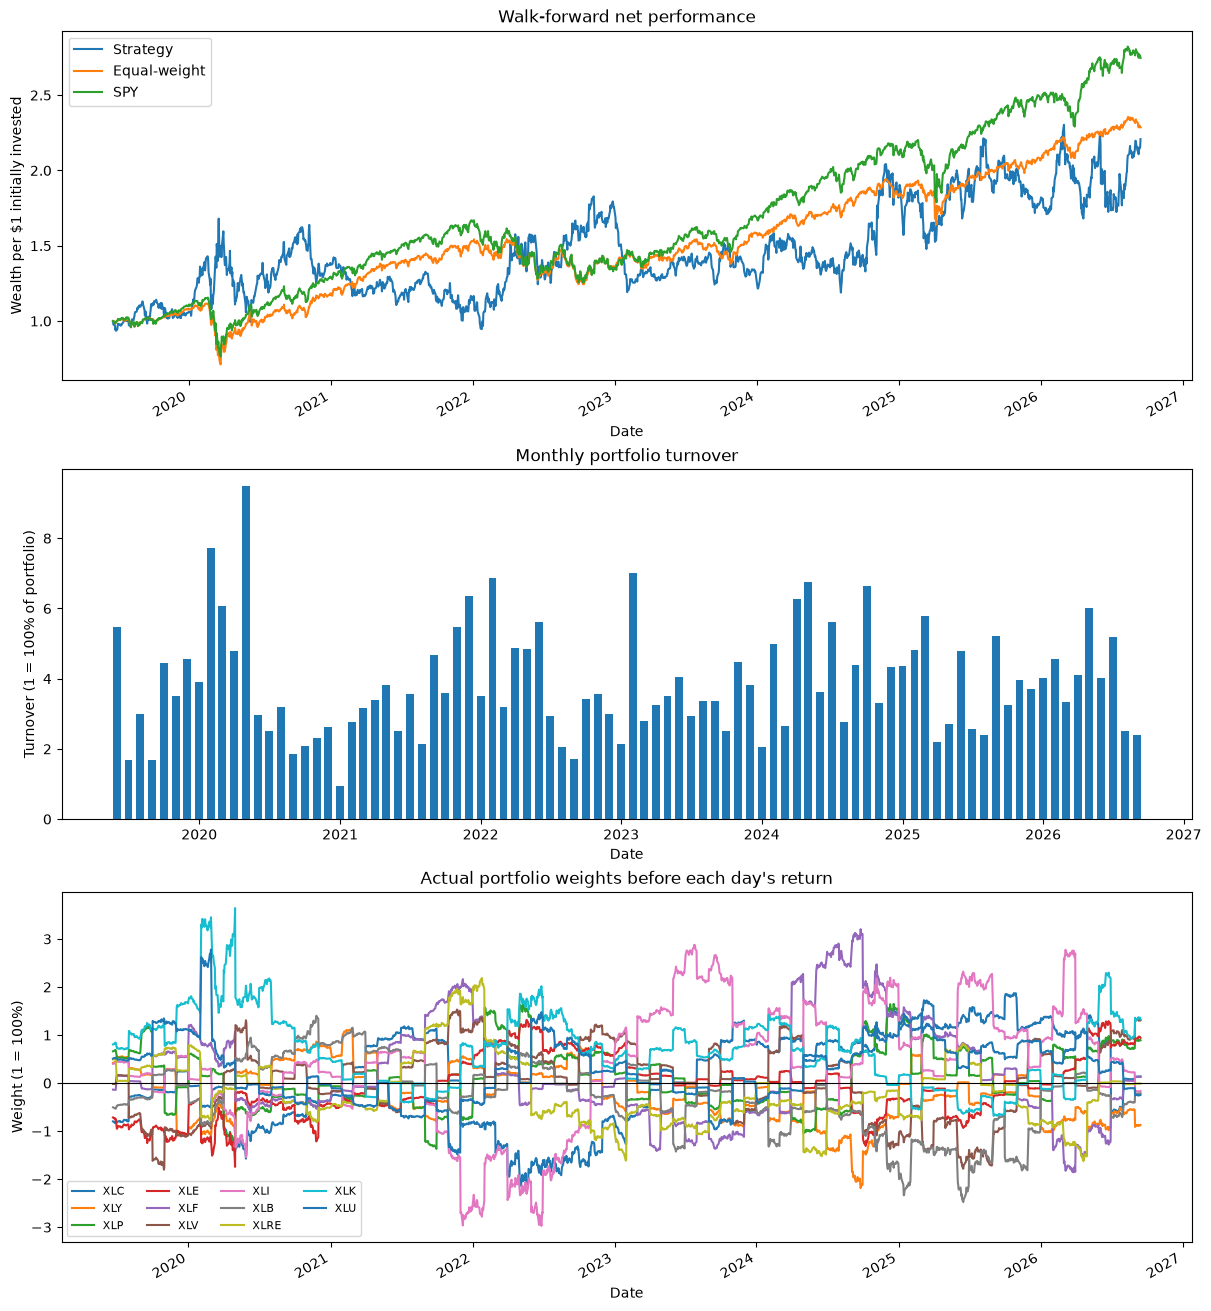

In [ ]:
fig, axes = plt.subplots(
    3, 1, figsize=(12, 13), constrained_layout=True
)

# Include initial capital so drawdowns from the starting value are visible.
start_date = sector_returns.index[window - 1]
wealth_plot = pd.concat([
    pd.DataFrame(1.0, index=[start_date], columns=wealth_5.columns),
    wealth_5,
])

wealth_plot.plot(ax=axes[0])
axes[0].set_title("Walk-forward net performance")
axes[0].set_ylabel("Wealth per $1 initially invested")
axes[0].set_xlabel("Date")

monthly_turnover = walkforward["Turnover"].resample("MS").sum()
axes[1].bar(
    monthly_turnover.index,
    monthly_turnover.values,
    width=20,
)
axes[1].set_title("Monthly portfolio turnover")
axes[1].set_ylabel("Turnover (1 = 100% of portfolio)")
axes[1].set_xlabel("Date")

held_weights_5.plot(ax=axes[2])
axes[2].set_title("Actual portfolio weights before each day's return")
axes[2].set_ylabel("Weight (1 = 100%)")
axes[2].set_xlabel("Date")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].legend(ncol=4, fontsize=8)

plt.show()

I would not recommend allocating capital to this strategy in its current form, since its annualized net return of 11.60% is below both equal-weight at 12.15% and SPY at 15.04%. It also takes substantially more risk, with annualized volatility of 40.41%, a maximum drawdown of 43.68%, and a Sharpe ratio of 0.47 compared with 0.71 and 0.81 for the benchmarks. Annualized turnover of 47.17 times portfolio value and total trading costs and management fees of 30.11% of initial capital over the full backtest add to the concerns about implementation. Given the noisy estimates in Section 2 and extreme allocations in Section 3, I would first test exposure limits and ways to reduce turnover. I would only reconsider funding if those changes improved sharpe ratios on some eval period.

### 5.3 — Interpretation

Write a paragraph (or two) addressing each of the following:

- Does the walk-forward strategy beat the benchmarks? If yes, where does the outperformance come from? If no, why not?
- How did transaction costs change your conclusion relative to the frictionless result in Section 4.1?
- What did the weight time series reveal? Did the optimizer concentrate in a small number of sectors, or did it diversify? Was this stable over time?
- If you were managing this portfolio with real money, what changes would you make? Point specifically to findings from Sections 2 and 3 to support your answer.

In [ ]:
# Hold targets, trading dates, and the evaluation period fixed to isolate costs.
def replay_walkforward(cost_bps_replay, fee_bps_replay):
    drifted_replay = np.zeros(len(sectors))
    net_returns_replay = []
    for date in walkforward.index:
        turnover_replay = 0.0
        held_replay = drifted_replay.copy()
        if walkforward.loc[date, "Rebalanced"]:
            held_replay = target_weights_5.loc[date].to_numpy()
            turnover_replay = np.abs(held_replay - drifted_replay).sum()
        cost_fraction_replay = cost_bps_replay / 10_000 * turnover_replay
        asset_return_replay = sector_returns.loc[date].to_numpy()
        growth_replay = (
            (1 - cost_fraction_replay) * (1 + held_replay @ asset_return_replay)
            - fee_bps_replay / 10_000 / 252
        )
        if growth_replay <= 0:
            raise ValueError("Replay exhausted portfolio equity.")
        drifted_replay = (
            (1 - cost_fraction_replay) * held_replay
            * (1 + asset_return_replay) / growth_replay
        )
        net_returns_replay.append(growth_replay - 1)
    return pd.Series(net_returns_replay, index=walkforward.index)

cost_comparison_53 = pd.DataFrame({
    "No costs or fees": replay_walkforward(0, 0),
    "Management fee only": replay_walkforward(0, fee_bps),
    "Trading costs and fee": replay_walkforward(cost_bps, fee_bps),
})
assert np.allclose(cost_comparison_53["Trading costs and fee"], walkforward["Net return"])
cost_metrics_53 = pd.DataFrame({
    "Annualized return": (1 + cost_comparison_53).prod() ** (252 / len(walkforward)) - 1,
    "Sharpe": cost_comparison_53.mean() / cost_comparison_53.std() * np.sqrt(252),
})
display(cost_metrics_53)

gross_53 = held_weights_5.abs().sum(axis=1)
largest_share_53 = held_weights_5.abs().max(axis=1) / gross_53
print(f"Median gross exposure: {gross_53.median():.2f}×; maximum: {gross_53.max():.2f}×")
print(f"Median largest sector share of gross exposure: {largest_share_53.median():.1%}")
print("Most frequent largest absolute position:")
display(held_weights_5.abs().idxmax(axis=1).value_counts().head())


,Annualized return,Sharpe
No costs or fees,0.148394,0.544274
Management fee only,0.142708,0.531964
Trading costs and fee,0.116041,0.473558


Median gross exposure: 7.22×; maximum: 13.23×
Median largest sector share of gross exposure: 21.5%
Most frequent largest absolute position:


XLI    483
XLK    372
XLC    333
XLF    234
XLB    208
Name: count, dtype: int64

The walk-forward strategy does not beat the benchmarks, with an annualized net return of 11.60% compared with 12.15% for equal-weight and 15.04% for SPY. Its Sharpe ratio is also lower at 0.47 versus 0.71 and 0.81, while volatility is more than twice that of either benchmark. I would say the extra exposure is not being rewarded here, and the noisy estimates from a 252-day window are a plausible reason for the unstable allocations, although this backtest alone does not prove the cause. Costs reinforce the unfavorable conclusion from the frictionless results in 4.1, where the model already underperformed both benchmarks. Since 4.1 uses a different period and fixed weights, I compared the same walk-forward targets and trading dates with and without costs: annualized return falls from 14.84% without costs or fees to 14.27% with the management fee alone, and then to 11.60% with trading costs included. Sharpe falls from 0.54 to 0.47 overall, so trading costs reduce performance substantially but are not the only issue.

The weight series shows changing long and short positions rather than a stable allocation across sectors. XLI is the largest absolute position most often, followed by XLK and XLC, and the median largest sector share of gross exposure is about 21.5%. This suggests the portfolio is not usually dominated by just one sector, but holding several sectors does not guarantee low risk: median gross exposure is 7.22 times capital and reaches 13.23 times. With real money, I would first test gross-exposure and position limits, given the sensitivity shown in Section 3 and the lower exposure achieved with constraints in 3.5. I would also test shrinking the mean estimates, as in 3.2, or a minimum-variance alternative, given the large mean-estimation errors in 2.1 and the changing estimates in 2.3. Less frequent trading or a penalty on turnover could help with costs, but I would evaluate these changes on separate data before assuming they improve the strategy.

## Section 6 — Bonus: Push the Strategy Further (Optional, up to 5 extra points)

Everything above gets you a defensible, honestly-evaluated strategy. If you want to see how it stacks up against other approaches a real desk might consider, pick **one** of the following and add it to your backtest comparison:

- A **minimum-variance** portfolio (ignore $\boldsymbol{\mu}$ entirely and minimize risk) as an additional benchmark.
- A **risk-parity** portfolio (weights inversely proportional to volatility, or the full risk-parity solution) as an additional benchmark.
- A simple **momentum overlay**: tilt $\hat{\boldsymbol{\mu}}$ toward recent trailing returns before optimizing, and see whether it helps or hurts out-of-sample.

Briefly explain your choice and what it revealed relative to your Section 5 strategy. This section is not required for full credit on the assignment — it's here for students who want to keep exploring.

,Annualized return,Annualized volatility,Sharpe ratio,Maximum drawdown
Original strategy,11.60%,40.41%,0.47,-43.68%
Equal-weight,12.15%,18.44%,0.71,-36.20%
SPY,15.04%,19.62%,0.81,-33.76%
Momentum overlay,8.20%,42.99%,0.40,-43.07%


,Annualized turnover,Total costs / initial capital,Median gross exposure,Maximum gross exposure
Original strategy,47.17×,30.11%,7.22×,13.23×
Momentum overlay,51.11×,34.10%,7.58×,15.50×


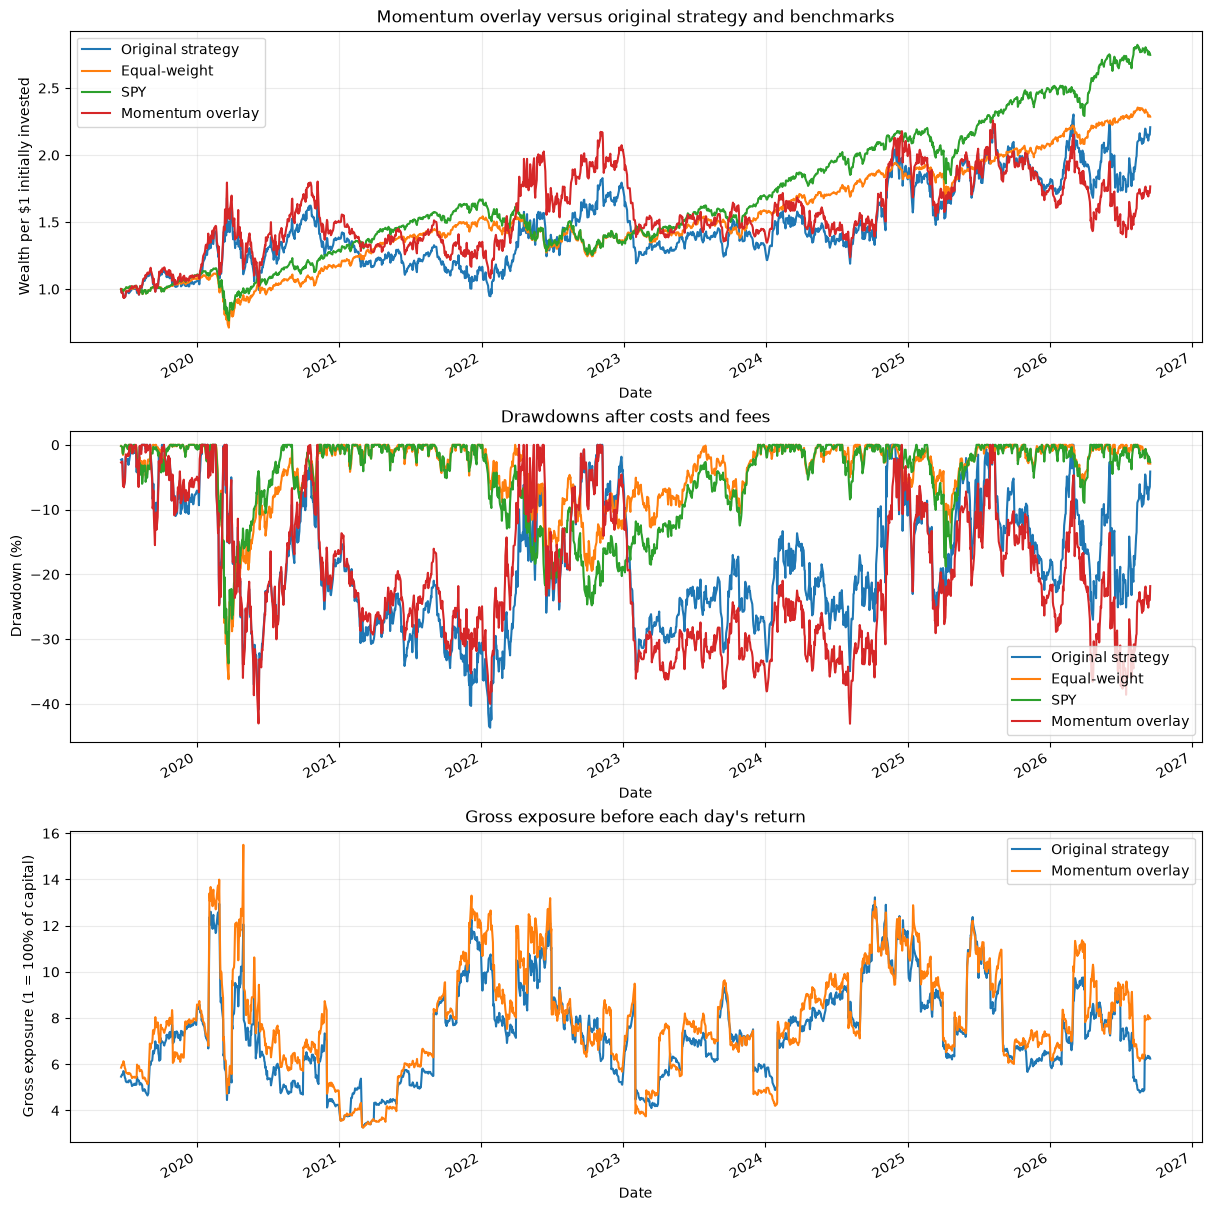

In [ ]:
momentum_window = 126
momentum_blend = 0.25

# Match Section 5's settings and evaluation period.
c_momentum = cost_bps / 10_000
daily_fee_momentum = fee_bps / 10_000 / 252

drifted_momentum = np.zeros(len(sectors))
wealth_momentum = 1.0

momentum_records = []
momentum_weights = []

for date in walkforward.index:
    t = sector_returns.index.get_loc(date)

    # Today's return is excluded from estimation.
    history = sector_returns.iloc[t - window:t]

    mu_long = history.mean().to_numpy()
    mu_recent = history.tail(momentum_window).mean().to_numpy()

    mu_overlay = (
        (1 - momentum_blend) * mu_long
        + momentum_blend * mu_recent
    )
    cov_t = history.cov().to_numpy()

    target = optimal_weights(mu_overlay, cov_t, gamma_base)

    turnover = 0.0
    held = drifted_momentum.copy()

    # Use exactly the same trading dates as Section 5.
    if walkforward.loc[date, "Rebalanced"]:
        turnover = np.abs(target - drifted_momentum).sum()
        held = target.copy()

    cost_fraction = c_momentum * turnover
    if cost_fraction >= 1:
        raise ValueError(f"Trading costs exhaust capital on {date}.")

    today_returns = sector_returns.loc[date].to_numpy()
    gross_return = held @ today_returns

    # Same cost and fee convention as Section 5.
    net_growth = (
        (1 - cost_fraction) * (1 + gross_return)
        - daily_fee_momentum
    )

    if net_growth <= 0:
        raise ValueError(f"Portfolio equity exhausted on {date}.")

    wealth_before = wealth_momentum
    wealth_momentum *= net_growth

    drifted_momentum = (
        (1 - cost_fraction)
        * held
        * (1 + today_returns)
        / net_growth
    )

    momentum_records.append({
        "Date": date,
        "Net return": net_growth - 1,
        "Wealth": wealth_momentum,
        "Turnover": turnover,
        "Trading cost": wealth_before * cost_fraction,
        "Management fee": wealth_before * daily_fee_momentum,
    })
    momentum_weights.append(held.copy())

momentum_run = pd.DataFrame(momentum_records).set_index("Date")
momentum_weights = pd.DataFrame(
    momentum_weights,
    index=momentum_run.index,
    columns=sectors,
)

# Compare all portfolios over the same dates.
returns_6 = returns_5.rename(
    columns={"Strategy": "Original strategy"}
).copy()
returns_6["Momentum overlay"] = momentum_run["Net return"]

assert returns_6.notna().all().all()

wealth_6 = (1 + returns_6).cumprod()
years_6 = len(returns_6) / 252
volatility_6 = returns_6.std(ddof=1) * np.sqrt(252)
drawdown_6 = wealth_6 / wealth_6.cummax().clip(lower=1) - 1

metrics_6 = pd.DataFrame({
    "Annualized return": wealth_6.iloc[-1] ** (1 / years_6) - 1,
    "Annualized volatility": volatility_6,
    "Sharpe ratio": (
        returns_6.mean() * 252 / volatility_6.replace(0, np.nan)
    ),
    "Maximum drawdown": drawdown_6.min(),
})

display(metrics_6.style.format({
    "Annualized return": "{:.2%}",
    "Annualized volatility": "{:.2%}",
    "Sharpe ratio": "{:.2f}",
    "Maximum drawdown": "{:.2%}",
}))

# Exposure and implementation costs for the two model strategies.
implementation_6 = pd.DataFrame({
    "Original strategy": {
        "Annualized turnover": walkforward["Turnover"].sum() / years_6,
        "Total costs / initial capital": (
            walkforward["Trading cost"].sum()
            + walkforward["Management fee"].sum()
        ),
        "Median gross exposure": held_weights_5.abs().sum(axis=1).median(),
        "Maximum gross exposure": held_weights_5.abs().sum(axis=1).max(),
    },
    "Momentum overlay": {
        "Annualized turnover": momentum_run["Turnover"].sum() / years_6,
        "Total costs / initial capital": (
            momentum_run["Trading cost"].sum()
            + momentum_run["Management fee"].sum()
        ),
        "Median gross exposure": momentum_weights.abs().sum(axis=1).median(),
        "Maximum gross exposure": momentum_weights.abs().sum(axis=1).max(),
    },
}).T

display(implementation_6.style.format({
    "Annualized turnover": "{:.2f}×",
    "Total costs / initial capital": "{:.2%}",
    "Median gross exposure": "{:.2f}×",
    "Maximum gross exposure": "{:.2f}×",
}))

# Performance and exposure plots.
fig, axes = plt.subplots(
    3, 1, figsize=(12, 12), constrained_layout=True
)

start_date = sector_returns.index[
    sector_returns.index.get_loc(returns_6.index[0]) - 1
]
wealth_plot_6 = pd.concat([
    pd.DataFrame(1.0, index=[start_date], columns=wealth_6.columns),
    wealth_6,
])

wealth_plot_6.plot(ax=axes[0])
axes[0].set_title("Momentum overlay versus original strategy and benchmarks")
axes[0].set_ylabel("Wealth per $1 initially invested")

(drawdown_6 * 100).plot(ax=axes[1])
axes[1].set_title("Drawdowns after costs and fees")
axes[1].set_ylabel("Drawdown (%)")

pd.DataFrame({
    "Original strategy": held_weights_5.abs().sum(axis=1),
    "Momentum overlay": momentum_weights.abs().sum(axis=1),
}).plot(ax=axes[2])
axes[2].set_title("Gross exposure before each day's return")
axes[2].set_ylabel("Gross exposure (1 = 100% of capital)")

for ax in axes:
    ax.set_xlabel("Date")
    ax.grid(alpha=0.25)

plt.show()

I chose a momentum overlay to see whether giving recent returns more weight would improve the strategy, blending 25% of the 126-day mean with 75% of the original 252-day mean. Increasing the momentum window from 63 to 126 days improved annualized net return from 2.86% to 8.20% and Sharpe from 0.30 to 0.40, while reducing volatility from 47.81% to 42.99%. However, it still underperformed the original strategy's 11.60% return and 0.47 Sharpe, with only a slightly smaller maximum drawdown of 43.07% versus 43.68%. I would say the longer window helped make the overlay less reactive, but giving recent returns extra weight did not improve the overall result relative to Section 5. This is consistent with the concern that shorter-window mean estimates can add noise, although the comparison does not establish the cause of the underperformance. Since I changed the window after seeing the initial results, I would treat this as an exploratory comparison rather than evidence that 126 days is the best choice.